# 02 — Analisis Hubungan Antar-Variabel (Perak, Emas, Dollar Index)

**Skripsi:** Implementasi *Time Series Foundation Model* Chronos-2 untuk Peramalan Probabilistik Harga Perak dengan Variabel Kovariat Harga Emas dan Dollar Index

Notebook ini adalah pelaporan **Tujuan Penelitian 1**: menyelidiki keterkaitan antara Perak, Emas, dan Dollar Index — apakah ketiganya bergerak bersama, pada lag berapa, dan ke arah mana presedensi prediktifnya. Ini bukan tahap pendukung untuk memilih kovariat, melainkan tujuan penelitian yang berdiri sendiri dengan temuannya sendiri, terpisah dari peramalan probabilistik (Tujuan 2).

**Ruang lingkup dan batasannya:**

- Seluruh komputasi diimpor dari `src/relationship_analysis.py` dan `src/mutual_information.py`. Tidak ada uji statistik, transformasi log-return, maupun logika pembagian data yang ditulis ulang di notebook ini. Fokusnya adalah *penyajian dan interpretasi*, bukan komputasi.
- Hanya `data/processed/train.csv` yang dimuat. Bagian 0 membuktikannya secara eksplisit lewat `assert` — data validasi dan data uji tidak pernah disentuh.
- Hasil uji Granger causality (prosedur Toda-Yamamoto) **tidak pernah** ditulis sebagai sebab-akibat di notebook ini. Istilah yang dipakai konsisten adalah "presedensi prediktif" atau "X Granger-cause Y". `src.relationship_analysis.assert_no_causal_language` memindai otomatis setiap teks interpretasi yang dibangun oleh kode di bawah.
- Urutan bagian mengikuti urutan wajib analisis: stasioneritas → autokorelasi → cross-correlation → kointegrasi → pemilihan lag VAR → Granger (Toda-Yamamoto) → diagnostik residual → Mutual Information sebagai pelengkap non-linear → sintesis. Tiap langkah menentukan validitas langkah berikutnya.

**Delapan gambar yang dihasilkan bagian ini** (dpi 300): `relationship/stationarity_comparison.png`, `relationship/acf_pacf_grid.png`, `relationship/ccf_perak_emas.png`, `relationship/ccf_perak_dxy.png`, `relationship/var_lag_selection.png`, `mutual_information/mi_vs_ccf.png`, `mutual_information/mi_permutation_null.png`, `relationship/scatter_level_vs_return.png` (seluruhnya di bawah `results/figures/`).

In [1]:
import json
import sys
from pathlib import Path

# Tambahkan akar project ke sys.path agar `import src.*` bekerja dari folder notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Seluruh komputasi analisis hubungan berasal dari src/
from src.relationship_analysis import (
    assert_no_causal_language,
    cross_correlation,
    diagnose_var_residuals,
    fit_var_with_ljungbox_escalation,
    granger_toda_yamamoto,
    granger_toda_yamamoto as run_granger,
    load_train_data,
    plot_acf_pacf,
    plot_cross_correlation,
    select_var_lag,
    test_cointegration,
    test_stationarity,
)
from src.relationship_analysis import _SERIES_COLORS as SERIES3_COLORS  # biru, oranye, hijau

# Mutual Information (pelengkap non-linear, Bagian 8) berasal dari src/mutual_information.py
from src.mutual_information import (
    MODE_LABELS,
    MODE_LEVEL,
    MODE_LOG_RETURN,
    compute_linear_correlations,
    compute_mi_lagged,
    compute_mi_matrix,
    compute_mi_stable,
    permutation_null_distribution,
    plot_mi_barplot,
    transform_frame,
)
from src.mutual_information import _SERIES_COLORS as _MI_COLORS  # biru, oranye (2 kovariat)

from src.preprocessing import get_covariate_columns, get_target_column
from src.utils import load_config, resolve_path, setup_logger

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300          # aturan umum notebook: seluruh figure dpi=300
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CONFIG = load_config()
RA_CONFIG = CONFIG["relationship_analysis"]
ALPHA = RA_CONFIG["alpha"]

TARGET_COL = get_target_column(CONFIG)
COVARIATE_COLS = get_covariate_columns(CONFIG)
ALL_COLUMNS = [TARGET_COL, *COVARIATE_COLS]

FIGURES_DIR = resolve_path(CONFIG["paths"]["figures_dir"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "relationship").mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "mutual_information").mkdir(parents=True, exist_ok=True)

NOTEBOOK_LOGGER = setup_logger(
    "notebook_analisis_hubungan", log_dir=CONFIG.get("paths", {}).get("logs_dir", "logs")
)

TICKERS = {spec["column"]: spec["ticker"] for spec in CONFIG["data"]["tickers"].values()}
DISPLAY_NAMES = {"silver": "Perak", "gold": "Emas", "dxy": "DXY"}
NAMES = {
    spec["column"]: DISPLAY_NAMES.get(key, key.upper())
    for key, spec in CONFIG["data"]["tickers"].items()
}
PAIR_LABELS = {c: f"{NAMES[TARGET_COL]}\u2013{NAMES[c]}" for c in COVARIATE_COLS}

SERIES_COLORS = dict(zip(ALL_COLUMNS, SERIES3_COLORS))          # 3 seri: perak, emas, dxy
COVARIATE_COLORS = dict(zip(COVARIATE_COLS, _MI_COLORS))        # 2 kovariat: emas, dxy

print("Target        :", TARGET_COL, f"({TICKERS[TARGET_COL]})")
print("Kovariat      :", ", ".join(f"{c} ({TICKERS[c]})" for c in COVARIATE_COLS))
print("Alfa (seluruh uji):", ALPHA)
print("Parameter analisis hubungan:", json.dumps(
    {k: v for k, v in RA_CONFIG.items() if k not in ("alpha",)}, indent=2, default=str
))

Target        : silver_close (SI=F)
Kovariat      : gold_close (GC=F), dxy_close (DX-Y.NYB)
Alfa (seluruh uji): 0.05
Parameter analisis hubungan: {
  "stationarity_regression": "c",
  "acf_pacf": {
    "mode": "logreturn",
    "lags": 40
  },
  "cross_correlation": {
    "max_lag": 10
  },
  "cointegration": {
    "johansen_det_order": 0,
    "aux_maxlags": 10
  },
  "var_lag_selection": {
    "maxlags": 20
  },
  "diagnostics": {
    "ljungbox_lags": 10,
    "arch_lags": 10
  },
  "figure_dpi": 200
}


## Bagian 0 — Bukti tidak ada kebocoran data

`load_train_data()` hanya membaca `data/processed/train.csv`. Batas tanggal tiap split **dibaca** dari `results/metrics/data_quality_report.json` (keluaran `src/preprocessing.py`), bukan dihitung ulang di sini — bila logika pembagian data ditulis ulang di notebook, angkanya bisa diam-diam menyimpang dari yang benar-benar dipakai pipeline.

Blok `assert` di bawah adalah bukti formal yang dapat ditunjukkan langsung ke penguji: bila satu saja observasi periode validasi atau uji ikut terbawa ke analisis hubungan ini, sel ini gagal dan notebook berhenti.

In [2]:
train = load_train_data(config=CONFIG)

report_path = resolve_path(CONFIG["paths"]["metrics_dir"]) / "data_quality_report.json"
with report_path.open("r", encoding="utf-8") as file:
    SPLIT_INFO = json.load(file)["split"]["splits"]

train_start = pd.Timestamp(SPLIT_INFO["train"]["date_start"])
train_end = pd.Timestamp(SPLIT_INFO["train"]["date_end"])
val_start = pd.Timestamp(SPLIT_INFO["val"]["date_start"])
test_start = pd.Timestamp(SPLIT_INFO["test"]["date_start"])

# --- BUKTI TIDAK ADA KEBOCORAN DATA ---
assert train.index.max() == train_end, (
    f"Tanggal maksimum data yang dimuat ({train.index.max().date()}) harus SAMA dengan "
    f"batas akhir split latih ({train_end.date()})."
)
assert train.index.min() == train_start, "Tanggal awal data latih tidak sesuai laporan split."
assert len(train) == SPLIT_INFO["train"]["n_rows"], "Jumlah baris tidak sesuai laporan split."
assert train.index.max() < val_start, "Data latih menyentuh periode VALIDASI!"
assert train.index.max() < test_start, "Data latih menyentuh periode UJI!"
assert train.index.is_monotonic_increasing, "Indeks tanggal tidak terurut."
assert not train.index.has_duplicates, "Ada tanggal duplikat."

print("BUKTI TIDAK ADA KEBOCORAN DATA")
print("=" * 72)
print(f"  Berkas yang dimuat        : data/processed/train.csv  (HANYA berkas ini)")
print(f"  Jumlah baris              : {len(train)}  "
      f"(laporan preprocessing: {SPLIT_INFO['train']['n_rows']})")
print(f"  Tanggal awal data latih   : {train.index.min().date()}")
print(f"  Tanggal MAKSIMUM data     : {train.index.max().date()}")
print(f"  Batas akhir split latih   : {train_end.date()}   <-- SAMA PERSIS")
print("-" * 72)
print(f"  Awal periode validasi     : {val_start.date()}  "
      f"({(val_start - train.index.max()).days} hari setelah akhir data latih)")
print(f"  Awal periode uji          : {test_start.date()}  "
      f"({(test_start - train.index.max()).days} hari setelah akhir data latih)")
print("=" * 72)
print("Seluruh assert lolos: data validasi dan data uji TIDAK disentuh oleh analisis ini.")

train.head()

2026-09-16 00:47:45 | INFO     | relationship_analysis | Memuat data latih: 879 baris (2021-08-16 s.d. 2025-02-12) dari D:\project-skripsi\data\processed\train.csv
2026-09-16 00:47:45 | INFO     | relationship_analysis | Data validasi dan data uji TIDAK dibaca (mencegah kebocoran data).
BUKTI TIDAK ADA KEBOCORAN DATA
  Berkas yang dimuat        : data/processed/train.csv  (HANYA berkas ini)
  Jumlah baris              : 879  (laporan preprocessing: 879)
  Tanggal awal data latih   : 2021-08-16
  Tanggal MAKSIMUM data     : 2025-02-12
  Batas akhir split latih   : 2025-02-12   <-- SAMA PERSIS
------------------------------------------------------------------------
  Awal periode validasi     : 2025-02-13  (1 hari setelah akhir data latih)
  Awal periode uji          : 2025-11-11  (272 hari setelah akhir data latih)
Seluruh assert lolos: data validasi dan data uji TIDAK disentuh oleh analisis ini.


,silver_close,gold_close,dxy_close
date,,,
2021-08-16,23.7800,"1,786.9000",92.6300
2021-08-17,23.6480,"1,785.0000",93.1300
2021-08-18,23.4120,"1,781.6000",93.1400
2021-08-19,23.2200,"1,780.2000",93.5700
2021-08-20,23.1050,"1,781.0000",93.5000


## Bagian 1 — Stasioneritas

ADF menguji hipotesis nol "seri memiliki *unit root*" (non-stasioner); KPSS menguji hipotesis nol sebaliknya, "seri stasioner". Keduanya dipasangkan justru karena arah kesalahannya berlawanan — bila sepakat, kesimpulannya jauh lebih meyakinkan daripada memakai satu uji saja. Bila keduanya bertentangan pada satu transformasi, transformasi itu ditandai **tidak konklusif**, bukan dipaksa memilih salah satu.

`test_stationarity()` menjalankan kedua uji pada level dan pada log-return sekaligus, lalu menyimpulkan ordo integrasi *d* dari kombinasi keduanya.

In [3]:
STATIONARITY_REGRESSION = RA_CONFIG["stationarity_regression"]

stationarity = {
    column: test_stationarity(train[column], column, alpha=ALPHA, regression=STATIONARITY_REGRESSION)
    for column in ALL_COLUMNS
}

stationarity_rows = []
for column in ALL_COLUMNS:
    result = stationarity[column]
    for transform_key, transform_label in (("level", "Level"), ("log_return", "Log-return")):
        block = result[transform_key]
        for test_name, test_result in (("ADF", block["adf"]), ("KPSS", block["kpss"])):
            stationarity_rows.append({
                "Seri": NAMES[column],
                "Transformasi": transform_label,
                "Uji": test_name,
                "Statistik": test_result["statistic"],
                "p-value": test_result["p_value"],
                "Crit. 5%": test_result["critical_values"]["5%"],
                "Kesimpulan uji": "stasioner" if test_result["stationary"] else "non-stasioner",
                "Kesimpulan gabungan": (
                    "TIDAK KONKLUSIF" if block["verdict"] == "tidak_konklusif" else block["verdict"]
                ),
            })

stationarity_table = pd.DataFrame(stationarity_rows).set_index(["Seri", "Transformasi", "Uji"])


def _highlight_inconclusive(row):
    flag = row["Kesimpulan gabungan"] == "TIDAK KONKLUSIF"
    return ["background-color:#fff3cd" if flag else "" for _ in row]


stationarity_table.style.apply(_highlight_inconclusive, axis=1)

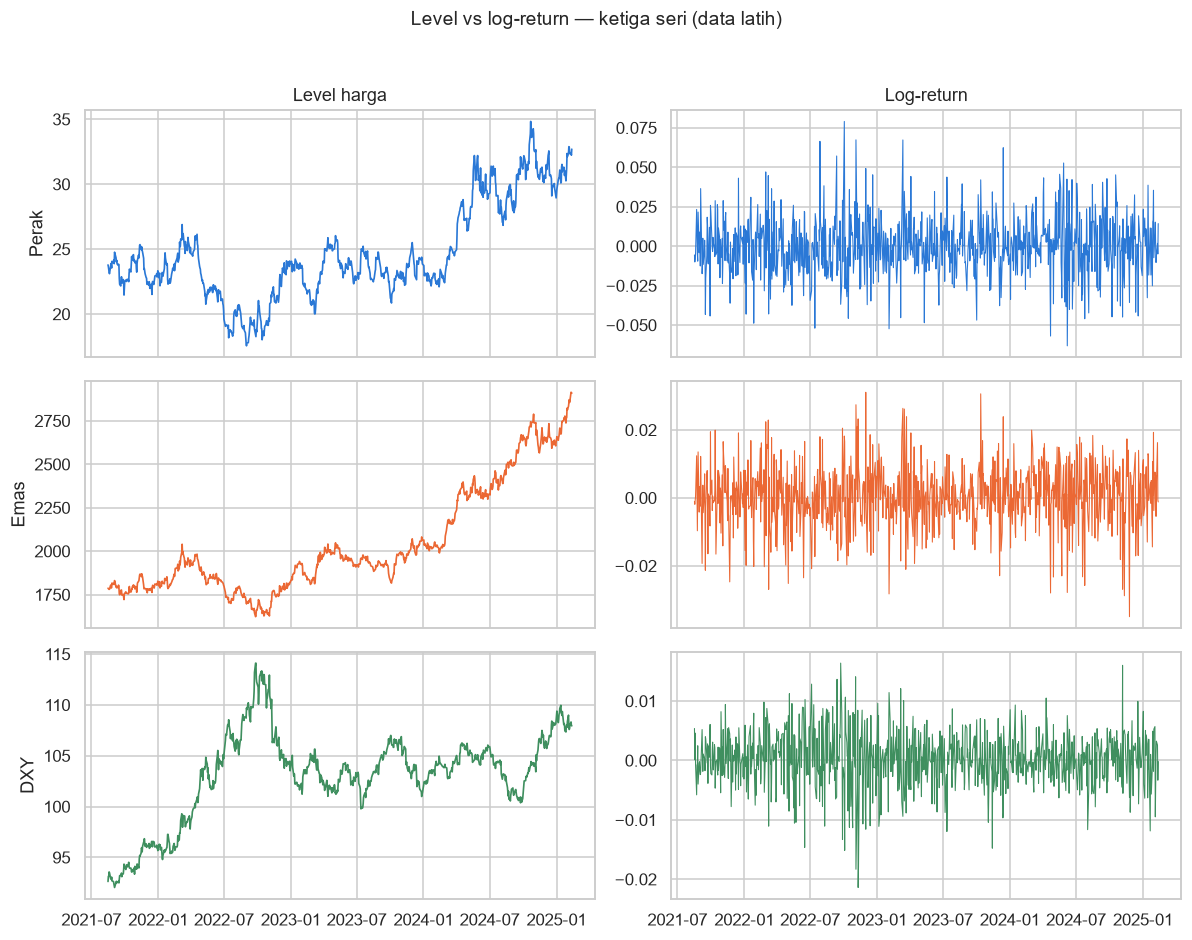

Tersimpan: D:\project-skripsi\results\figures\relationship\stationarity_comparison.png


In [4]:
# Item 3: level vs log-return berdampingan untuk ketiga seri
log_return_train = transform_frame(train, "log_return", ALL_COLUMNS)

fig, axes = plt.subplots(len(ALL_COLUMNS), 2, figsize=(11, 2.9 * len(ALL_COLUMNS)), sharex="col")

for row, column in enumerate(ALL_COLUMNS):
    color = SERIES_COLORS[column]
    axes[row, 0].plot(train.index, train[column], color=color, linewidth=1.1)
    axes[row, 1].plot(log_return_train.index, log_return_train[column], color=color, linewidth=0.7)
    axes[row, 0].set_ylabel(NAMES[column])

axes[0, 0].set_title("Level harga")
axes[0, 1].set_title("Log-return")
fig.suptitle("Level vs log-return \u2014 ketiga seri (data latih)", fontsize=12.5)
fig.tight_layout(rect=(0, 0, 1, 0.96))

stationarity_fig_path = FIGURES_DIR / "relationship" / "stationarity_comparison.png"
fig.savefig(stationarity_fig_path)
plt.show()
print("Tersimpan:", stationarity_fig_path)

**Ordo integrasi tiap seri (data latih):**

Ketiga seri — Perak, Emas, dan Dollar Index — non-stasioner pada level (ADF gagal menolak *unit root*, KPSS menolak stasioneritas, keduanya sepakat) dan menjadi stasioner setelah ditransformasi menjadi log-return (ADF menolak *unit root*, KPSS gagal menolak stasioneritas, keduanya sepakat lagi). Ordo integrasinya karena itu **d = 1** untuk ketiga seri. Panel kanan pada gambar di atas menunjukkan alasannya secara visual: level harga bergerak sebagai lintasan bertren yang tidak kembali ke rata-rata tertentu, sedangkan log-return berosilasi rapat di sekitar nol tanpa arah yang jelas — persis ciri deret stasioner.

Angka *d* ini bukan sekadar catatan metodologis: nilai maksimumnya (di sini **d_max = 1**, karena ketiganya sama-sama d = 1) menjadi jumlah lag tambahan yang disisipkan pada prosedur Toda-Yamamoto di Bagian 6. Prosedur itu mengestimasi VAR pada **level** dengan `p + d_max` lag alih-alih `p` saja, justru supaya uji presedensi prediktifnya tetap sah tanpa perlu mengetahui pasti apakah seri-serinya terkointegrasi (Bagian 4) — cukup tahu ordo integrasi maksimumnya, yang sudah diperoleh di sini.

## Bagian 2 — Struktur autokorelasi (ACF/PACF)

`plot_acf_pacf()` menggambar ACF dan PACF log-return ketiga seri sekaligus, 40 lag, dengan pita kepercayaan 95% di bawah hipotesis nol "tidak ada autokorelasi". Dipakai pada log-return, bukan level — pada level, ACF/PACF akan didominasi tren bersama dan tidak informatif, persis alasan yang sama dengan Bagian 1.

Tersimpan: D:\project-skripsi\results\figures\relationship\acf_pacf_grid.png


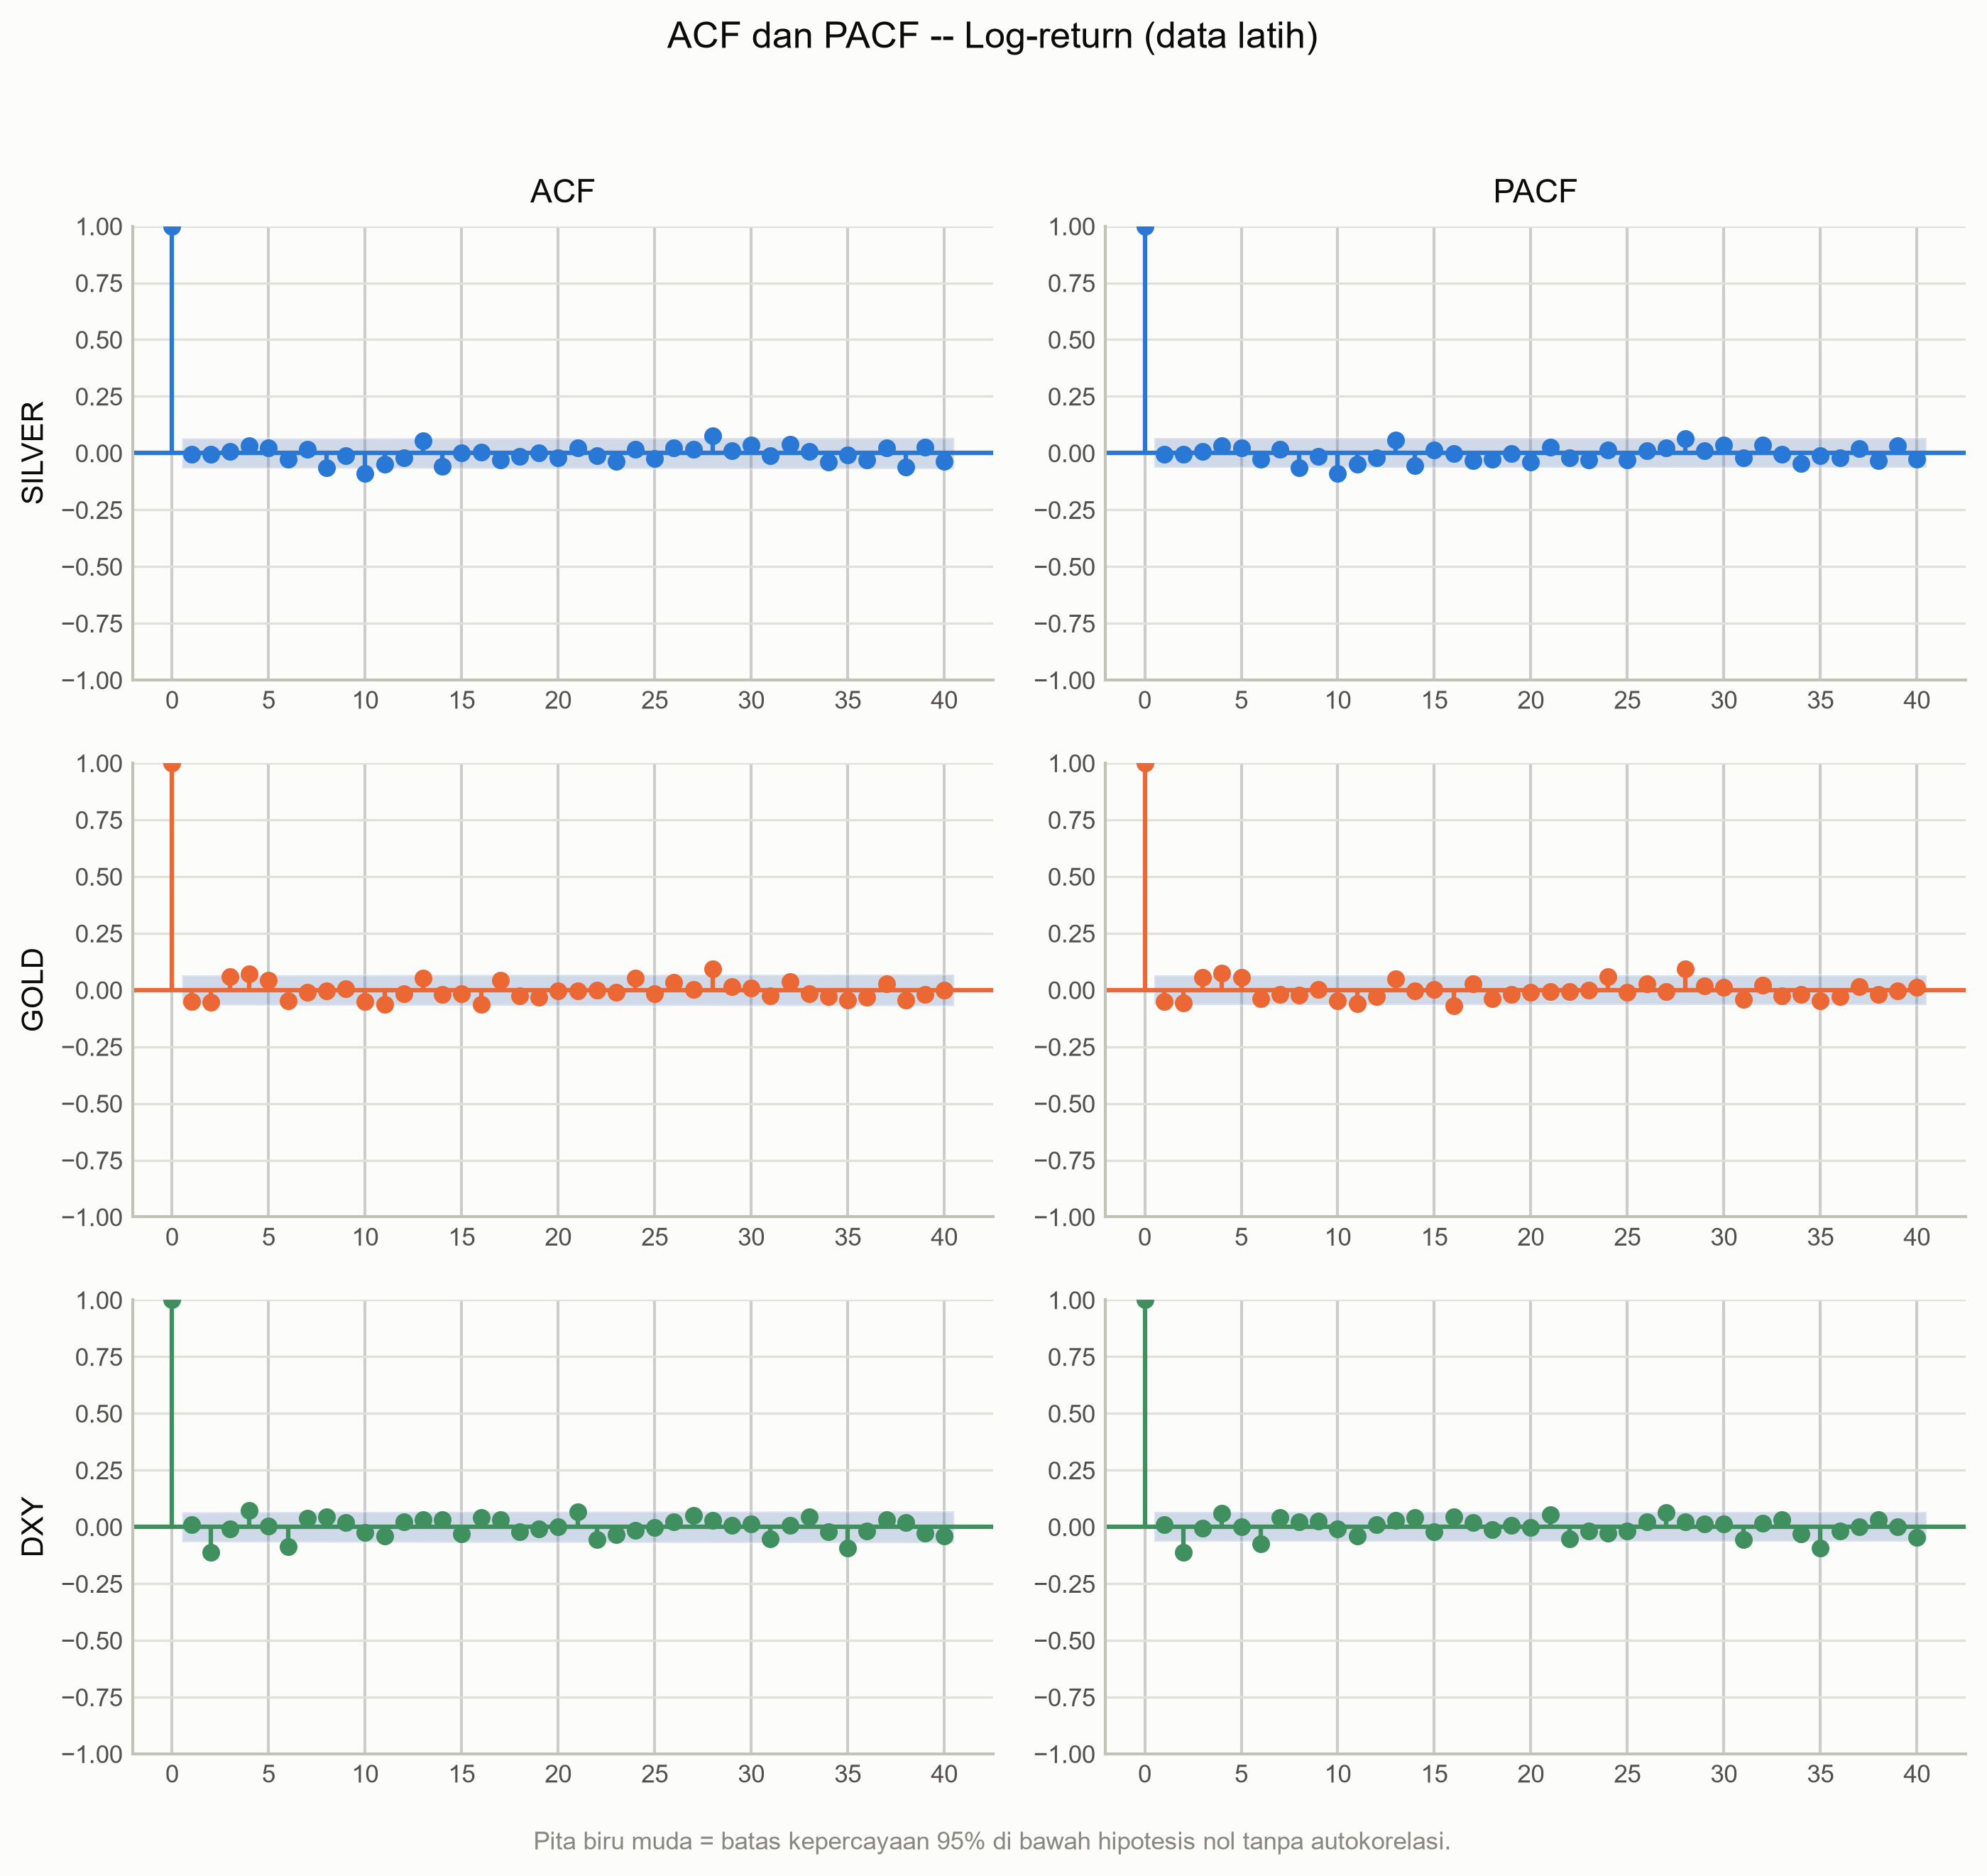

In [5]:
acf_pacf_path = plot_acf_pacf(
    train,
    mode=RA_CONFIG["acf_pacf"]["mode"],
    lags=RA_CONFIG["acf_pacf"]["lags"],
    output_path=FIGURES_DIR / "relationship" / "acf_pacf_grid.png",
    dpi=300,
)
print("Tersimpan:", acf_pacf_path)
display(Image(filename=str(acf_pacf_path)))

Hampir seluruh lag berada di dalam pita kepercayaan 95% pada ketiga seri — nyaris tidak ada autokorelasi signifikan pada lag rendah (lag 1–3). Ini **wajar** untuk return finansial harian dan sejalan dengan gagasan pasar yang mendekati efisien (informasi hari ini cepat terserap ke harga, sehingga return hari berikutnya sulit ditebak dari return hari ini). Sebagian kecil lag yang menonjol di luar pita (mis. sekitar lag 4 pada Emas dan DXY, dan lag yang lebih jauh pada Perak) mengindikasikan struktur temporal residual yang tipis — cukup untuk membuat pemilihan lag VAR pada Bagian 5–7 tidak berhenti di lag 1, tetapi tidak cukup untuk membentuk pola autokorelasi yang kuat. Temuan "nyaris tidak ada" ini sengaja disebutkan secara eksplisit, bukan dilewati diam-diam — ketiadaan pola adalah temuan yang sah untuk data return harian.

## Bagian 3 — Cross-correlation function (CCF)

`cross_correlation(x, y)` memakai konvensi tanda `CCF(lag) = corr(x_t, y_{t+lag})`. **Lag positif berarti *x* mendahului *y***: nilai `x` hari ini dipasangkan dengan nilai `y` di masa depan. Di sini `x` = kovariat dan `y` = Perak, sehingga **lag positif = kovariat mendahului Perak**, dan **lag negatif = Perak mendahului kovariat**. Salah tafsir tanda ini membalik seluruh kesimpulan arah presedensi, karena itu `plot_cross_correlation()` menuliskannya langsung sebagai label sumbu-x pada gambar — bukan hanya di teks ini.

Dihitung pada log-return (bukan level) dengan alasan yang sama seperti Bagian 1–2: pada level, CCF akan tinggi semu di seluruh lag akibat tren bersama.

Tersimpan (Perak–Emas): D:\project-skripsi\results\figures\relationship\ccf_perak_emas.png


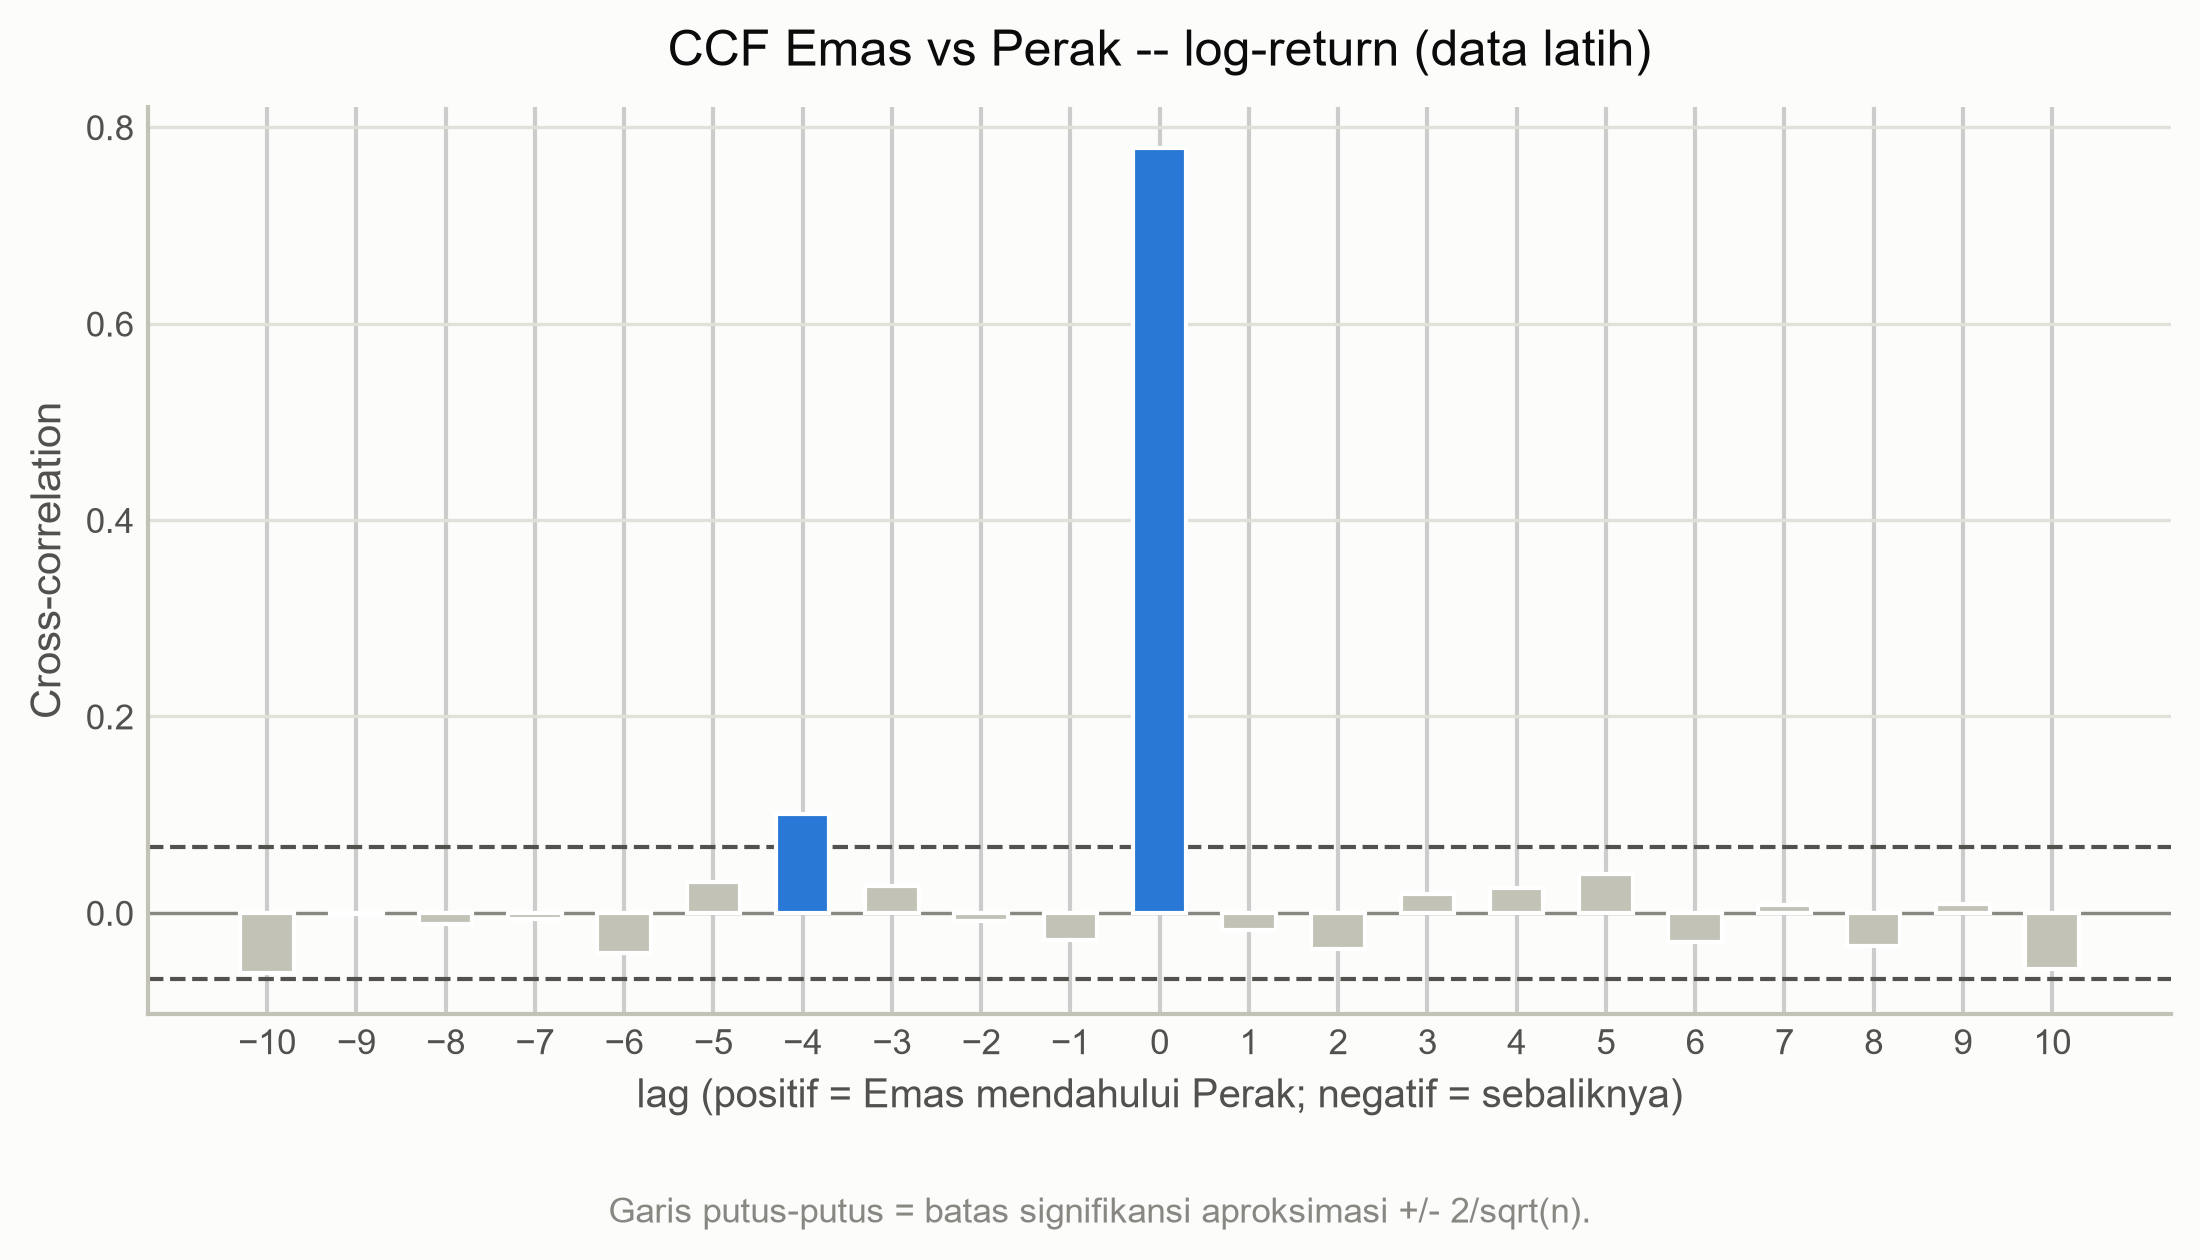

Tersimpan (Perak–DXY): D:\project-skripsi\results\figures\relationship\ccf_perak_dxy.png


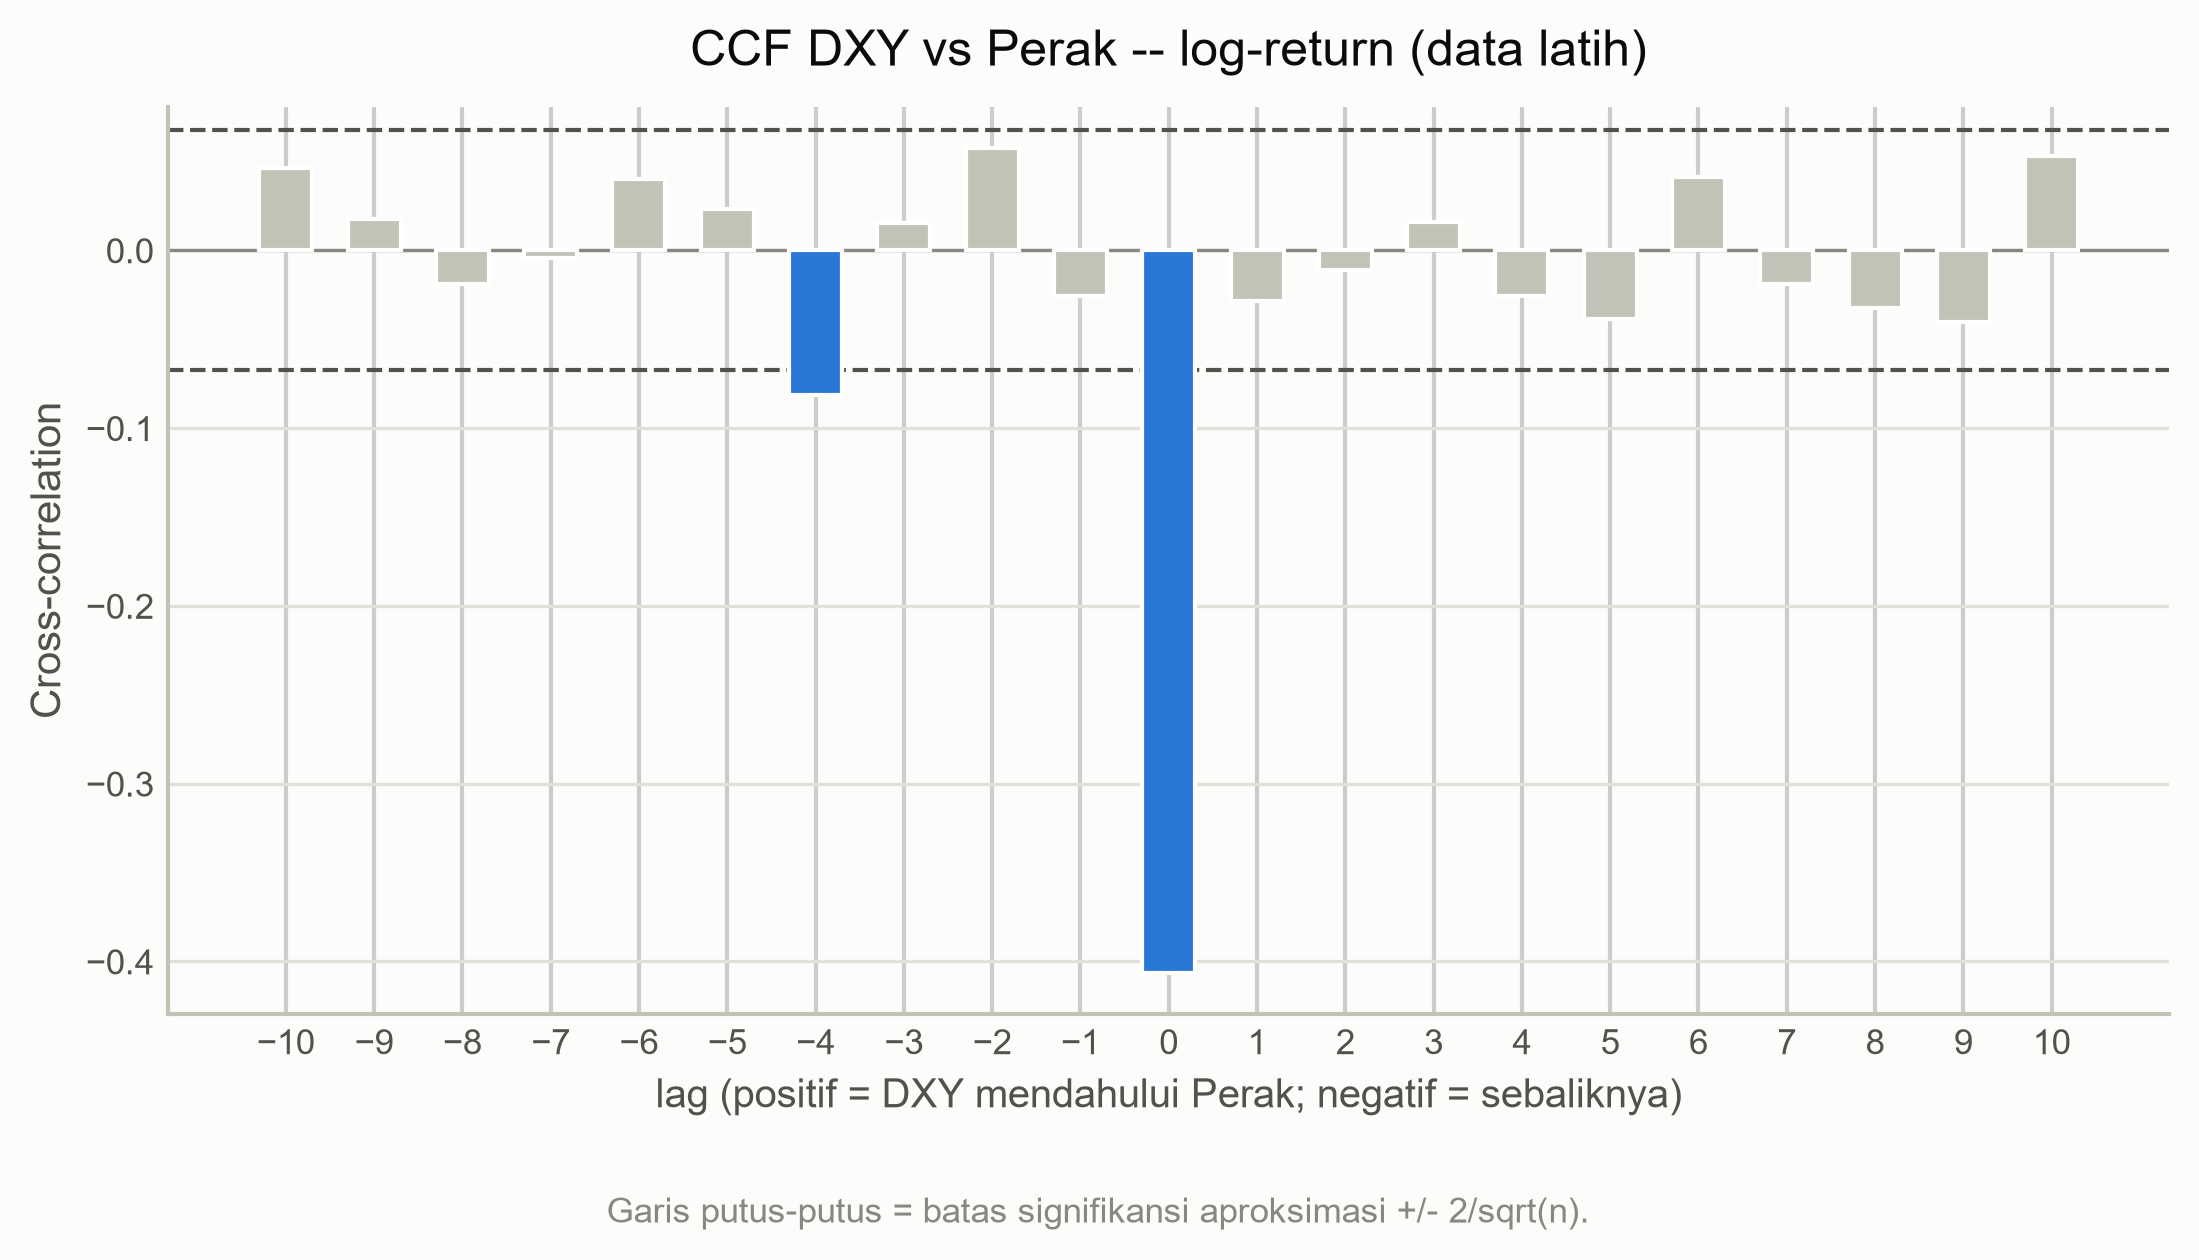

,Lag |CCF| puncak,CCF pada lag puncak,Batas signifikansi (2/√n),Signifikan
Pasangan,,,,
Perak–Emas,0,0.7785,0.0675,True
Perak–DXY,0,-0.4063,0.0675,True


In [6]:
CCF_MAX_LAG = RA_CONFIG["cross_correlation"]["max_lag"]
CCF_FIGURE_NAMES = {}
if len(COVARIATE_COLS) >= 1:
    CCF_FIGURE_NAMES[COVARIATE_COLS[0]] = "ccf_perak_emas.png"
if len(COVARIATE_COLS) >= 2:
    CCF_FIGURE_NAMES[COVARIATE_COLS[1]] = "ccf_perak_dxy.png"

ccf_results = {}
ccf_peak_rows = []

for covariate in COVARIATE_COLS:
    ccf_df = cross_correlation(
        log_return_train[covariate], log_return_train[TARGET_COL], max_lag=CCF_MAX_LAG
    )
    ccf_results[covariate] = ccf_df

    figure_name = CCF_FIGURE_NAMES.get(covariate, f"ccf_perak_{covariate}.png")
    ccf_fig_path = plot_cross_correlation(
        ccf_df,
        x_label=NAMES[covariate],
        y_label=NAMES[TARGET_COL],
        output_path=FIGURES_DIR / "relationship" / figure_name,
        dpi=300,
    )
    print(f"Tersimpan ({PAIR_LABELS[covariate]}):", ccf_fig_path)
    display(Image(filename=str(ccf_fig_path)))

    peak_row = ccf_df.loc[ccf_df["ccf"].abs().idxmax()]
    ccf_peak_rows.append({
        "Pasangan": PAIR_LABELS[covariate],
        "Lag |CCF| puncak": int(peak_row["lag"]),
        "CCF pada lag puncak": peak_row["ccf"],
        "Batas signifikansi (2/\u221an)": peak_row["signif_bound"],
        "Signifikan": bool(peak_row["significant"]),
    })

ccf_peak_table = pd.DataFrame(ccf_peak_rows).set_index("Pasangan")
ccf_peak_table

Kedua pasangan mencapai korelasi silang absolut tertinggi pada **lag 0** — sezaman, bukan berlag. Ini bukan kesalahan atau kebetulan: lag 0 yang dominan konsisten dengan Bagian 2 (autokorelasi harian yang nyaris tidak ada) dan menjadi peringatan dini bahwa uji Granger pada Bagian 6, yang secara eksplisit menguji lag ≥ 1, kemungkinan tidak akan menemukan presedensi prediktif berlag meskipun keterkaitan sezamannya kuat.

## Bagian 4 — Kointegrasi

Dijalankan pada **level**, bukan log-return — kointegrasi adalah relasi keseimbangan jangka panjang antar-level harga (mis. rasio emas-perak yang dikenal luas), yang justru hilang bila datanya dibedakan. `test_cointegration()` menjalankan Engle-Granger per pasangan (kedua arah) dan Johansen pada sistem ketiga seri sekaligus (uji trace dan max-eigenvalue).

In [7]:
COINT_SETTINGS = RA_CONFIG["cointegration"]
cointegration = test_cointegration(
    train,
    alpha=ALPHA,
    johansen_det_order=COINT_SETTINGS["johansen_det_order"],
    aux_maxlags=COINT_SETTINGS["aux_maxlags"],
)

engle_granger_table = pd.DataFrame([
    {
        "Pasangan (y0~y1)": key,
        "Statistik EG": r["statistic"],
        "p-value": r["p_value"],
        "Crit. 5%": r["critical_values"]["5%"],
        "Kointegrasi (alfa=0.05)": "ya" if r["cointegrated"] else "tidak",
    }
    for key, r in cointegration["engle_granger"].items()
]).set_index("Pasangan (y0~y1)")

engle_granger_table

,Statistik EG,p-value,Crit. 5%,Kointegrasi (alfa=0.05)
Pasangan (y0~y1),,,,
silver_close~gold_close,-3.2826,0.0572,-3.3431,tidak
gold_close~silver_close,-2.6766,0.2081,-3.3431,tidak
silver_close~dxy_close,-0.6737,0.9494,-3.3431,tidak
dxy_close~silver_close,-2.1267,0.4624,-3.3431,tidak
gold_close~dxy_close,0.3388,0.9913,-3.3431,tidak
dxy_close~gold_close,-2.2961,0.3755,-3.3431,tidak


In [8]:
johansen = cointegration["johansen"]

trace_table = pd.DataFrame(johansen["trace_test"]).assign(Uji="trace")
max_eig_table = pd.DataFrame(johansen["max_eig_test"]).assign(Uji="max-eigenvalue")
johansen_table = (
    pd.concat([trace_table, max_eig_table], ignore_index=True)
    .rename(columns={
        "r_less_equal": "H0: rank \u2264 r",
        "statistic": "Statistik",
        "crit_90": "Crit. 90%",
        "crit_95": "Crit. 95%",
        "crit_99": "Crit. 99%",
        "reject_h0": "Tolak H0",
    })
    .set_index(["Uji", "H0: rank \u2264 r"])
)

print(
    f"Sistem: {', '.join(NAMES[c] for c in johansen['series'])}  |  "
    f"k_ar_diff = {johansen['k_ar_diff']} (lag bantu VAR level = {johansen['aux_lag_var']}, dipilih via AIC)"
)
print(f"Rank kointegrasi -- trace test: {johansen['rank_trace']}  |  max-eigenvalue test: {johansen['rank_max_eig']}")
johansen_table

Sistem: Perak, Emas, DXY  |  k_ar_diff = 0 (lag bantu VAR level = 1, dipilih via AIC)
Rank kointegrasi -- trace test: 1  |  max-eigenvalue test: 0


Statistik  Crit. 90%  Crit. 95%  Crit. 99%  \
Uji            H0: rank ≤ r                                               
trace          0               32.4802    27.0669    29.7961    35.4628   
               1               12.3753    13.4294    15.4943    19.9349   
               2                0.8761     2.7055     3.8415     6.6349   
max-eigenvalue 0               20.1049    18.8928    21.1314    25.8650   
               1               11.4992    12.2971    14.2639    18.5200   
               2                0.8761     2.7055     3.8415     6.6349   

                             Tolak H0  
Uji            H0: rank ≤ r            
trace          0                 True  
               1                False  
               2                False  
max-eigenvalue 0                False  
               1                False  
               2                False

Engle-Granger tidak menolak hipotesis nol "tidak terkointegrasi" untuk satu pun pasangan pada alfa 0,05 (seluruh p-value > 0,05, termasuk Perak-Emas yang p-valuenya paling kecil di antara semua pasangan namun masih di atas ambang). Johansen memberi gambaran yang sedikit berbeda antara kedua statistiknya: uji trace menunjukkan rank kointegrasi 1, sedangkan uji max-eigenvalue menunjukkan rank 0 — keduanya tidak sepenuhnya sepakat, situasi yang memang bisa terjadi pada sampel berhingga karena kedua statistik itu menguji hipotesis alternatif yang berbeda (trace: rank ≤ r versus rank lebih tinggi; max-eigenvalue: rank = r versus rank = r+1 tepat).

Ambiguitas kointegrasi semacam ini justru menjadi alasan metodologis memakai prosedur Toda-Yamamoto pada Bagian 6, bukan uji Granger standar pada data yang dibedakan atau model koreksi-kesalahan (VECM). Uji Granger standar maupun VECM mengharuskan peneliti terlebih dahulu memutuskan dengan pasti apakah dan pada rank berapa seri-seri itu terkointegrasi — keputusan yang keliru pada tahap ini akan menghasilkan spesifikasi model yang salah dan inferensi yang tidak sah. Toda-Yamamoto mengestimasi VAR pada level dengan lag tambahan sebesar ordo integrasi maksimum (Bagian 1), sehingga kesimpulan presedensi prediktifnya tetap valid **baik seri-serinya terkointegrasi maupun tidak** — kesimpulan Bagian 6 karena itu tidak bergantung pada hasil uji kointegrasi yang ambigu di atas.

## Bagian 5 — Pemilihan lag VAR

`select_var_lag()` memilih orde lag VAR pada level lewat empat kriteria informasi: AIC, BIC, HQIC, dan FPE, untuk maxlags 1 sampai 20. BIC dipakai sebagai hasil utama karena lebih konservatif (menghindari *overfitting* lag pada seri yang relatif pendek); AIC dilaporkan sebagai pemeriksaan ketahanan.

In [9]:
LAG_SETTINGS = RA_CONFIG["var_lag_selection"]
lag_selection = select_var_lag(train, maxlags=LAG_SETTINGS["maxlags"])

criteria_table = pd.DataFrame(lag_selection["criteria_table"]).set_index("lag")
minima_per_criterion = criteria_table.idxmin()


def _highlight_minima(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    for column in data.columns:
        styles.loc[minima_per_criterion[column], column] = "background-color:#dff0d8; font-weight:bold"
    return styles


print(
    f"Lag utama (BIC)              = {lag_selection['p_main']}\n"
    f"Lag pemeriksaan ketahanan (AIC) = {lag_selection['p_robustness']}\n"
    f"Kesenjangan besar antar-kriteria (>= 3 lag)? {lag_selection['large_discrepancy']}"
)
criteria_table.style.apply(_highlight_minima, axis=None)

Lag utama (BIC)              = 1
Lag pemeriksaan ketahanan (AIC) = 1
Kesenjangan besar antar-kriteria (>= 3 lag)? False


,aic,bic,hqic,fpe
lag,,,,
0,14.434928,14.451538,14.441287,1857846.275679
1,1.806388,1.872825,1.831824,6.088420
2,1.820528,1.936792,1.865041,6.175123
3,1.814493,1.980585,1.878083,6.137983
4,1.826836,2.042755,1.909503,6.214236
5,1.826650,2.092397,1.928394,6.213116
6,1.839505,2.155080,1.960326,6.293559
7,1.850211,2.215614,1.990109,6.361376
8,1.860713,2.275943,2.019688,6.428637


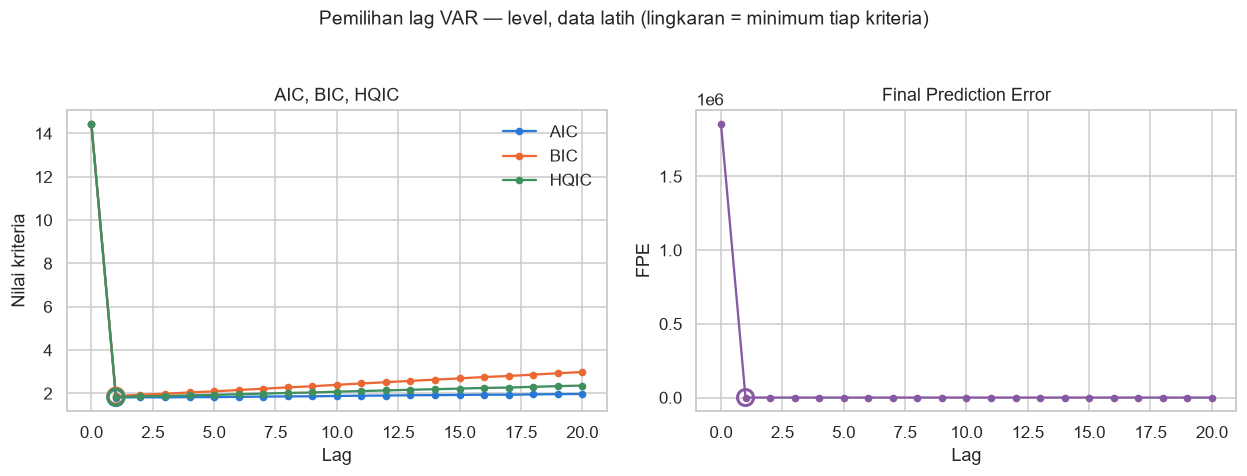

Tersimpan: D:\project-skripsi\results\figures\relationship\var_lag_selection.png


In [10]:
# Item 12 (lanjutan): visualisasi kurva kriteria informasi.
# FPE beda skala jauh dari AIC/BIC/HQIC (satuan varians galat, bukan log-likelihood),
# sehingga digambar pada panel terpisah.
fig, (ax_info, ax_fpe) = plt.subplots(1, 2, figsize=(11.5, 4.4))

info_criteria = {"aic": "#2a78d6", "bic": "#eb6834", "hqic": "#3f8f5f"}
for criterion, color in info_criteria.items():
    ax_info.plot(criteria_table.index, criteria_table[criterion], marker="o", markersize=4,
                 color=color, label=criterion.upper())
    best_lag = minima_per_criterion[criterion]
    ax_info.scatter([best_lag], [criteria_table.loc[best_lag, criterion]], s=110,
                     facecolor="none", edgecolor=color, linewidth=2, zorder=5)
ax_info.set_xlabel("Lag")
ax_info.set_ylabel("Nilai kriteria")
ax_info.set_title("AIC, BIC, HQIC")
ax_info.legend(frameon=False)

ax_fpe.plot(criteria_table.index, criteria_table["fpe"], marker="o", markersize=4, color="#8859a3")
best_fpe_lag = minima_per_criterion["fpe"]
ax_fpe.scatter([best_fpe_lag], [criteria_table.loc[best_fpe_lag, "fpe"]], s=110,
               facecolor="none", edgecolor="#8859a3", linewidth=2, zorder=5)
ax_fpe.set_xlabel("Lag")
ax_fpe.set_ylabel("FPE")
ax_fpe.set_title("Final Prediction Error")

fig.suptitle("Pemilihan lag VAR \u2014 level, data latih (lingkaran = minimum tiap kriteria)", fontsize=12.5)
fig.tight_layout(rect=(0, 0, 1, 0.94))

lag_fig_path = FIGURES_DIR / "relationship" / "var_lag_selection.png"
fig.savefig(lag_fig_path)
plt.show()
print("Tersimpan:", lag_fig_path)

BIC dan AIC memilih lag yang **sama persis**: p = 1 untuk keduanya (lihat cetakan di atas), sehingga tidak ada kesenjangan yang perlu dipertentangkan pada tahap ini (kesenjangan besar biasanya didefinisikan sebagai selisih ≥ 3 lag). Kesepakatan ini tidak serta-merta berarti spesifikasi p = 1 sudah layak dipakai — Bagian 7 menunjukkan bahwa lag ini masih perlu diperiksa lebih lanjut lewat diagnostik residual sebelum dipakai sebagai dasar uji presedensi prediktif.

## Bagian 6 — Granger causality (Toda-Yamamoto)

`granger_toda_yamamoto(df, p, d_max)` mengestimasi VAR pada level dengan `p + d_max` lag, lalu menguji Wald (kovarians HAC) hanya pada `p` koefisien lag pertama dari variabel yang diuji sebagai penyebab — lag tambahan `d_max` hanya penyesuai derajat integrasi, bukan bagian yang diuji. `d_max = 1` diambil dari kesimpulan Bagian 1.

Tabel di bawah memakai lag mentah hasil Bagian 5 (BIC dan AIC), **sebelum** diperiksa lewat diagnostik residual. Keabsahannya sebagai kesimpulan akhir masih bergantung pada Bagian 7 — bila diagnostik menolak, tabel di bawah belum bisa dipakai sebagai jawaban final (lihat Bagian 7).

In [11]:
D_MAX_VALUES = [stationarity[c]["order_of_integration"]["d"] for c in ALL_COLUMNS]
D_MAX = max((d for d in D_MAX_VALUES if d is not None), default=1)
if any(d is None for d in D_MAX_VALUES):
    D_MAX = max(D_MAX, 1)
print(f"d_max = {D_MAX} (ordo integrasi maksimum, dari Bagian 1: {dict(zip(ALL_COLUMNS, D_MAX_VALUES))})")

RELEVANT_PAIRS = (
    [f"{covariate}->{TARGET_COL}" for covariate in COVARIATE_COLS]
    + [f"{TARGET_COL}->{covariate}" for covariate in COVARIATE_COLS]
)


def granger_table(granger_result):
    rows = []
    for pair_key in RELEVANT_PAIRS:
        r = granger_result["pairs"][pair_key]
        rows.append({
            "Arah (X -> Y)": f"{NAMES[r['cause']]} -> {NAMES[r['effect']]}",
            "Lag diuji (p)": r["p"],
            "d_max": r["d_max"],
            "Statistik Wald": r["statistic"],
            "df": r["df"],
            "p-value": r["p_value"],
            "Kesimpulan (alfa=0.05)": (
                "ada presedensi prediktif" if r["significant"] else "tidak ada presedensi prediktif"
            ),
        })
    return pd.DataFrame(rows).set_index("Arah (X -> Y)")


granger_main_raw = run_granger(train, p=lag_selection["p_main"], d_max=D_MAX, robust="HAC")
granger_robust_raw = run_granger(train, p=lag_selection["p_robustness"], d_max=D_MAX, robust="HAC")

print(f"Tabel A -- lag utama, BIC (p = {lag_selection['p_main']}):")
display(granger_table(granger_main_raw))

print(f"\nTabel B -- lag pemeriksaan ketahanan, AIC (p = {lag_selection['p_robustness']}):")
display(granger_table(granger_robust_raw))

if lag_selection["p_main"] == lag_selection["p_robustness"]:
    print(
        "\nCatatan: BIC dan AIC memilih lag yang sama pada data ini "
        f"(p = {lag_selection['p_main']}), sehingga Tabel A dan Tabel B identik. "
        "Ini bukan duplikasi yang disengaja -- kedua kriteria memang bersepakat di sini."
    )

d_max = 1 (ordo integrasi maksimum, dari Bagian 1: {'silver_close': 1, 'gold_close': 1, 'dxy_close': 1})
Tabel A -- lag utama, BIC (p = 1):


,Lag diuji (p),d_max,Statistik Wald,df,p-value,Kesimpulan (alfa=0.05)
Arah (X -> Y),,,,,,
Emas -> Perak,1,1,0.3327,1,0.5641,tidak ada presedensi prediktif
DXY -> Perak,1,1,1.1536,1,0.2828,tidak ada presedensi prediktif
Perak -> Emas,1,1,0.0050,1,0.9436,tidak ada presedensi prediktif
Perak -> DXY,1,1,0.0180,1,0.8934,tidak ada presedensi prediktif



Tabel B -- lag pemeriksaan ketahanan, AIC (p = 1):


,Lag diuji (p),d_max,Statistik Wald,df,p-value,Kesimpulan (alfa=0.05)
Arah (X -> Y),,,,,,
Emas -> Perak,1,1,0.3327,1,0.5641,tidak ada presedensi prediktif
DXY -> Perak,1,1,1.1536,1,0.2828,tidak ada presedensi prediktif
Perak -> Emas,1,1,0.0050,1,0.9436,tidak ada presedensi prediktif
Perak -> DXY,1,1,0.0180,1,0.8934,tidak ada presedensi prediktif



Catatan: BIC dan AIC memilih lag yang sama pada data ini (p = 1), sehingga Tabel A dan Tabel B identik. Ini bukan duplikasi yang disengaja -- kedua kriteria memang bersepakat di sini.


Pada spesifikasi lag mentah ini, tidak satu pun dari keempat arah pengujian menunjukkan presedensi prediktif signifikan pada alfa 0,05 (seluruh p-value uji Wald jauh di atas 0,05). Dengan kata lain: **tidak ditemukan bukti bahwa Emas atau Dollar Index secara statistik Granger-cause Perak pada lag 1, maupun sebaliknya** — dan simetris untuk arah yang berlawanan. Namun kesimpulan ini masih berstatus sementara: ia baru sah dipakai setelah residual model VAR yang mendasarinya lolos diagnostik pada Bagian 7.

## Bagian 7 — Diagnostik residual VAR

Ljung-Box menguji H0 "residual tidak berautokorelasi"; ARCH-LM menguji H0 "tidak ada efek ARCH" (heteroskedastisitas bersyarat). Diagnostik dijalankan dulu pada model lag mentah (p = 1, hasil BIC/AIC dari Bagian 5) yang mendasari Bagian 6 di atas.

In [12]:
DIAG_SETTINGS = RA_CONFIG["diagnostics"]


def diagnostics_table(diagnostics):
    return pd.DataFrame([
        {
            "Variabel": NAMES[column],
            f"Ljung-Box p (lag={entry['ljung_box']['lags']})": entry["ljung_box"]["p_value"],
            "Lolos LB": "ya" if entry["ljung_box"]["pass"] else "TIDAK",
            f"ARCH-LM p (lag={entry['arch_lm']['lags']})": entry["arch_lm"]["p_value"],
            "Lolos ARCH": "ya" if entry["arch_lm"]["pass"] else "TIDAK",
        }
        for column, entry in diagnostics["per_variable"].items()
    ]).set_index("Variabel")


# maxlags = p_raw memaksa fungsi berhenti setelah SATU kali fit (tanpa eskalasi),
# sehingga diagnostik yang dikembalikan persis untuk model p = p_main di Bagian 6.
p_raw = lag_selection["p_main"]
_, _, diagnostics_raw = fit_var_with_ljungbox_escalation(
    train,
    p_start=p_raw,
    maxlags=p_raw,
    alpha=ALPHA,
    ljungbox_lags=DIAG_SETTINGS["ljungbox_lags"],
    arch_lags=DIAG_SETTINGS["arch_lags"],
    logger=NOTEBOOK_LOGGER,
)

print(f"Diagnostik pada lag mentah p = {p_raw} (model yang mendasari Bagian 6 di atas):")
diagnostics_table(diagnostics_raw)

PERINGATAN: Ljung-Box menolak H0 pada residual 'dxy_close' (p=0.0031) -- otokorelasi sisa terdeteksi, pertimbangkan menambah lag VAR dan mengestimasi ulang model.
Diagnostik pada lag mentah p = 1 (model yang mendasari Bagian 6 di atas):


,Ljung-Box p (lag=10),Lolos LB,ARCH-LM p (lag=10),Lolos ARCH
Variabel,,,,
Perak,0.0787,ya,0.0000,TIDAK
Emas,0.0958,ya,0.0000,TIDAK
DXY,0.0031,TIDAK,0.0000,TIDAK


Ljung-Box menolak H0 pada residual DXY (p-value di bawah 0,05) meskipun lolos untuk Perak dan Emas — artinya spesifikasi VAR pada lag mentah **belum menangkap seluruh struktur temporal pada persamaan DXY**. Konsekuensinya eksplisit: **tabel Granger pada Bagian 6 di atas belum valid untuk dijadikan kesimpulan akhir.** Analisis tidak berhenti di sini seolah-olah sudah lolos — lag dinaikkan dan model diestimasi ulang sampai Ljung-Box tidak lagi menolak H0 pada seluruh variabel.

In [13]:
p_final, var_final, diagnostics_final = fit_var_with_ljungbox_escalation(
    train,
    p_start=p_raw,
    maxlags=LAG_SETTINGS["maxlags"],
    alpha=ALPHA,
    ljungbox_lags=DIAG_SETTINGS["ljungbox_lags"],
    arch_lags=DIAG_SETTINGS["arch_lags"],
    logger=NOTEBOOK_LOGGER,
)
escalated = p_final != p_raw

print(f"Lag dinaikkan dari p = {p_raw} menjadi p = {p_final}." if escalated else "Tidak diperlukan eskalasi lag.")
print(f"\nDiagnostik pada lag akhir p = {p_final} (model yang divalidasi):")
diagnostics_table(diagnostics_final)

PERINGATAN: Ljung-Box menolak H0 pada residual 'dxy_close' (p=0.0031) -- otokorelasi sisa terdeteksi, pertimbangkan menambah lag VAR dan mengestimasi ulang model.
2026-09-16 00:47:50 | WARNING  | notebook_analisis_hubungan | Ljung-Box menolak H0 pada lag 1 -- menambah lag menjadi 2 dan mengestimasi ulang VAR.
PERINGATAN: Ljung-Box menolak H0 pada residual 'dxy_close' (p=0.0028) -- otokorelasi sisa terdeteksi, pertimbangkan menambah lag VAR dan mengestimasi ulang model.
2026-09-16 00:47:50 | WARNING  | notebook_analisis_hubungan | Ljung-Box menolak H0 pada lag 2 -- menambah lag menjadi 3 dan mengestimasi ulang VAR.
Lag dinaikkan dari p = 1 menjadi p = 3.

Diagnostik pada lag akhir p = 3 (model yang divalidasi):


,Ljung-Box p (lag=10),Lolos LB,ARCH-LM p (lag=10),Lolos ARCH
Variabel,,,,
Perak,0.0725,ya,0.0000,TIDAK
Emas,0.3774,ya,0.0000,TIDAK
DXY,0.2926,ya,0.0000,TIDAK


Pada lag akhir, Ljung-Box tidak lagi menolak H0 untuk ketiga variabel — spesifikasi ini lolos diagnostik autokorelasi residual dan layak dipakai sebagai dasar uji presedensi prediktif. ARCH-LM sebaliknya tetap menolak H0 pada ketiga variabel bahkan setelah lag dinaikkan — **ini wajar untuk data finansial** (volatilitas cenderung mengelompok/*clustering*) dan bukan indikasi kesalahan spesifikasi lag; menambah lag VAR tidak menghilangkan efek ARCH. Inilah justru alasan metodologis mengapa uji Wald pada prosedur Toda-Yamamoto memakai kovarians HAC (Newey-West): tanpa koreksi ini, p-value uji Wald akan terlalu kecil karena residualnya heteroskedastik.

In [14]:
# Granger tervalidasi -- inilah tabel yang dipakai sebagai jawaban akhir Bagian 6-7,
# bukan tabel A/B pada Bagian 6 yang masih berdasarkan lag mentah.
granger_validated = run_granger(train, p=p_final, d_max=D_MAX, robust="HAC")

print(f"Tabel Granger TERVALIDASI (lag akhir p = {p_final}, setelah diagnostik residual lolos):")
granger_validated_table = granger_table(granger_validated)
granger_validated_table

Tabel Granger TERVALIDASI (lag akhir p = 3, setelah diagnostik residual lolos):


,Lag diuji (p),d_max,Statistik Wald,df,p-value,Kesimpulan (alfa=0.05)
Arah (X -> Y),,,,,,
Emas -> Perak,3,1,3.9244,3,0.2697,tidak ada presedensi prediktif
DXY -> Perak,3,1,1.9615,3,0.5804,tidak ada presedensi prediktif
Perak -> Emas,3,1,4.4399,3,0.2177,tidak ada presedensi prediktif
Perak -> DXY,3,1,0.5253,3,0.9133,tidak ada presedensi prediktif


In [15]:
# Pengaman otomatis: setiap interpretasi Granger yang dibangun secara dinamis
# WAJIB lolos pemindaian bahasa non-kausal sebelum dicetak.
_interpretation_lines = [
    granger_validated["pairs"][pair_key]["interpretation"] for pair_key in RELEVANT_PAIRS
]
for line in _interpretation_lines:
    assert_no_causal_language(line)
    print("-", line)

- GOLD Granger-cause SILVER pada lag 1-3 (statistik Wald=3.924, df=3, p=0.2697): tidak ditemukan presedensi prediktif signifikan pada alfa 0.05.
- DXY Granger-cause SILVER pada lag 1-3 (statistik Wald=1.962, df=3, p=0.5804): tidak ditemukan presedensi prediktif signifikan pada alfa 0.05.
- SILVER Granger-cause GOLD pada lag 1-3 (statistik Wald=4.440, df=3, p=0.2177): tidak ditemukan presedensi prediktif signifikan pada alfa 0.05.
- SILVER Granger-cause DXY pada lag 1-3 (statistik Wald=0.525, df=3, p=0.9133): tidak ditemukan presedensi prediktif signifikan pada alfa 0.05.


Kesimpulan pada lag tervalidasi **tidak berubah** dari lag mentah: keempat arah pengujian tetap tidak menunjukkan presedensi prediktif signifikan pada alfa 0,05. Konsistensi ini memperkuat keyakinan pada kesimpulan "tidak ada presedensi prediktif berlag" — bukan karena kebetulan spesifikasi lag tertentu, tetapi karena ia bertahan baik pada lag mentah maupun lag yang sudah divalidasi diagnostiknya. Tabel pada sel ini, bukan Tabel A/B Bagian 6, yang dipakai sebagai rujukan pada sintesis akhir (Bagian 9).

## Bagian 8 — Mutual Information sebagai pelengkap non-linear

Granger causality (termasuk Toda-Yamamoto di atas) bersifat **linear** — ia hanya menguji apakah nilai lag masa lalu masuk secara linear ke persamaan target. Mutual Information (MI) menangkap ketergantungan berbentuk apa pun, linear maupun tidak. Ketidaksesuaian antara keduanya (mis. MI tinggi tapi Granger tidak signifikan) adalah **temuan yang dibahas**, bukan kegagalan salah satu metode.

Seperti Bagian 1–3, MI dilaporkan dalam dua varian: level (sesuai narasi awal) dan log-return (varian yang secara statistik sah, karena level didominasi tren bersama).

In [16]:
MI_SETTINGS = CONFIG["mutual_information"]
MODES = [MODE_LEVEL, MODE_LOG_RETURN]

mi_results = {
    mode: compute_mi_matrix(train, mode, config=CONFIG, run_permutation_test=True)
    for mode in MODES
}

comparison_rows = []
for covariate in COVARIATE_COLS:
    level_pair = mi_results[MODE_LEVEL]["pairs"][covariate]
    logret_pair = mi_results[MODE_LOG_RETURN]["pairs"][covariate]
    comparison_rows.append({
        "Pasangan": PAIR_LABELS[covariate],
        "MI level (nat)": level_pair["mi_mean"],
        "MI log-return (nat)": logret_pair["mi_mean"],
        "Pearson r (level)": level_pair["pearson"]["coefficient"],
        "Pearson r (log-return)": logret_pair["pearson"]["coefficient"],
        "Spearman rho (level)": level_pair["spearman"]["coefficient"],
        "Spearman rho (log-return)": logret_pair["spearman"]["coefficient"],
        "p permutasi (log-return)": logret_pair["permutation_test"]["p_value"],
    })

mi_comparison_table = pd.DataFrame(comparison_rows).set_index("Pasangan")
mi_comparison_table

,MI level (nat),MI log-return (nat),Pearson r (level),Pearson r (log-return),Spearman rho (level),Spearman rho (log-return),p permutasi (log-return)
Pasangan,,,,,,,
Perak–Emas,1.3477,0.4150,0.9324,0.7785,0.8464,0.7546,0.0010
Perak–DXY,0.7753,0.0899,-0.0187,-0.4063,-0.1533,-0.3959,0.0010


Tersimpan: D:\project-skripsi\results\figures\mutual_information\mi_barplot.png


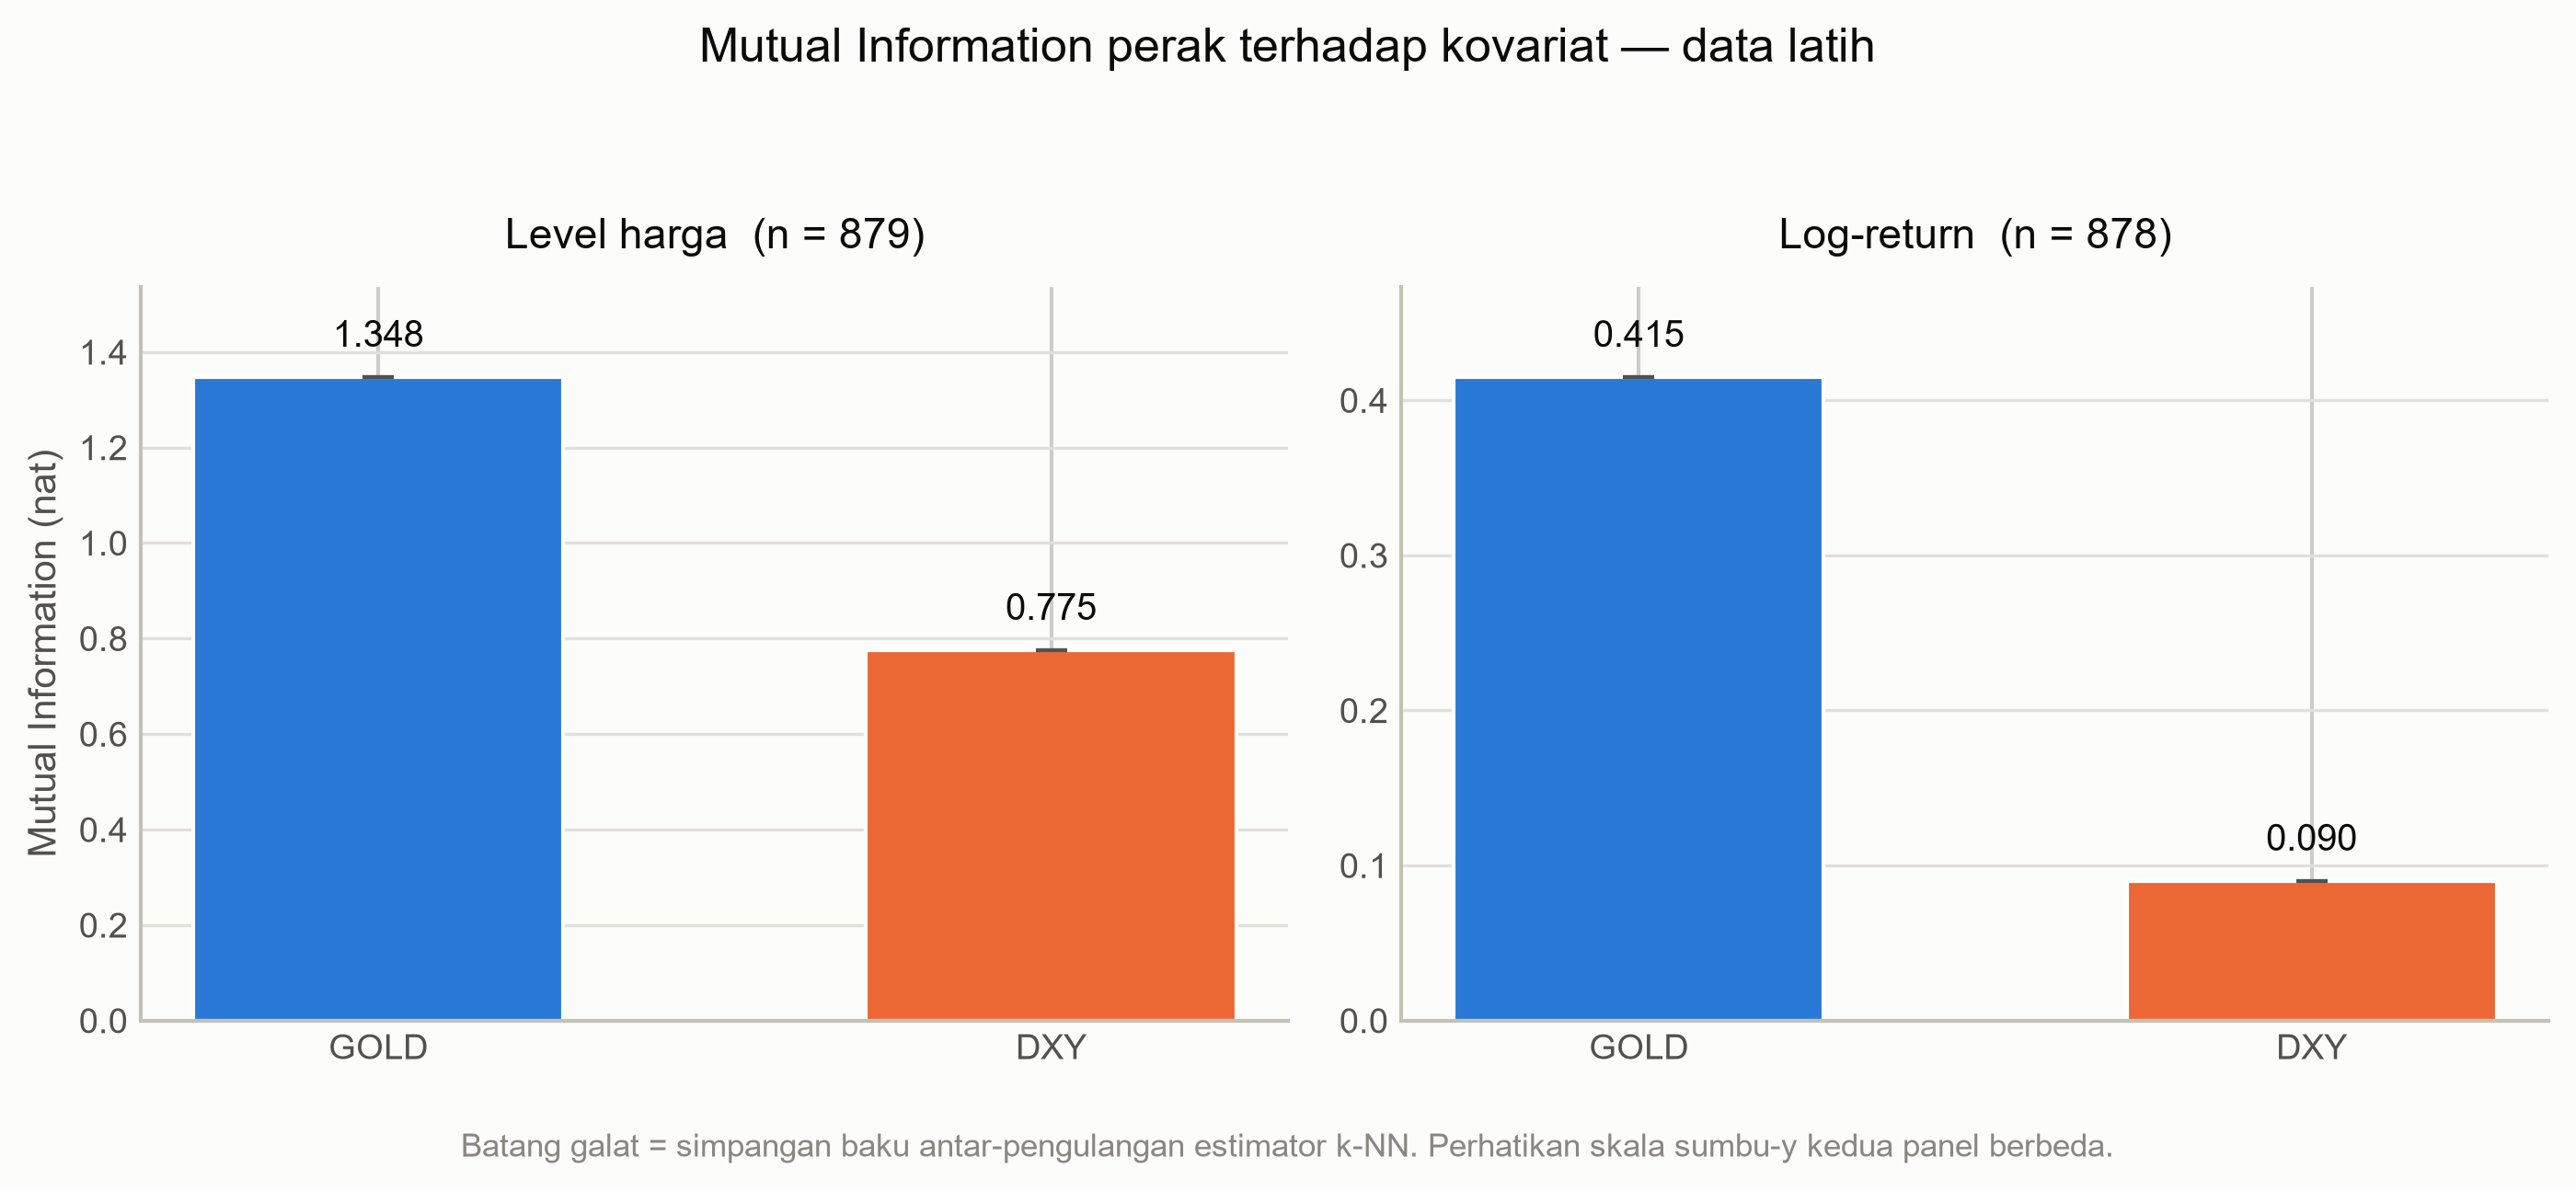

In [17]:
# Item 20: barplot MI dengan error bar, memakai plot_mi_barplot() langsung dari src/
mi_barplot_path = plot_mi_barplot(
    mi_results, output_path=FIGURES_DIR / "mutual_information" / "mi_barplot.png", dpi=300
)
print("Tersimpan:", mi_barplot_path)
display(Image(filename=str(mi_barplot_path)))

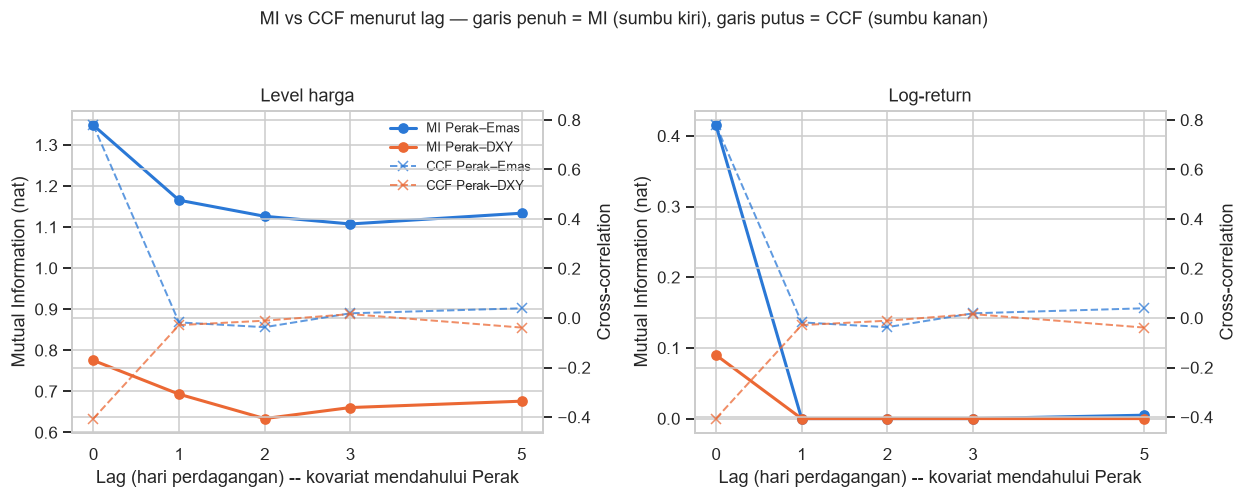

Tersimpan: D:\project-skripsi\results\figures\mutual_information\mi_vs_ccf.png


In [18]:
# Item 21: MI vs lag (0-5) disandingkan dengan CCF (Bagian 3) pada sumbu-x yang sama.
# Konvensi CCF: lag positif = kovariat mendahului Perak -- sama seperti sumbu lag pada MI berlag
# (target_t vs kovariat_{t-lag}), sehingga keduanya bisa dibandingkan langsung pada lag >= 0.
MI_LAGS = MI_SETTINGS["lags"]
mi_lagged = {mode: compute_mi_lagged(train, MI_LAGS, mode, config=CONFIG) for mode in MODES}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
twin_axes = []

for ax, mode in zip(axes, MODES):
    ax_ccf = ax.twinx()
    twin_axes.append(ax_ccf)
    for covariate in COVARIATE_COLS:
        color = COVARIATE_COLORS[covariate]
        series = mi_lagged[mode]["pairs"][covariate]
        means = [point["mi_mean"] for point in series]
        ax.plot(MI_LAGS, means, color=color, marker="o", linewidth=2.0,
                 label=f"MI {PAIR_LABELS[covariate]}", zorder=3)

        ccf_at_lags = ccf_results[covariate].set_index("lag").loc[MI_LAGS, "ccf"]
        ax_ccf.plot(MI_LAGS, ccf_at_lags.to_numpy(), color=color, linestyle="--",
                    marker="x", linewidth=1.3, alpha=0.75, label=f"CCF {PAIR_LABELS[covariate]}")

    ax.set_xlabel("Lag (hari perdagangan) -- kovariat mendahului Perak")
    ax.set_ylabel("Mutual Information (nat)")
    ax_ccf.set_ylabel("Cross-correlation")
    ax.set_title(MODE_LABELS[mode])
    ax.set_xticks(MI_LAGS)

lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = twin_axes[0].get_legend_handles_labels()
axes[0].legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, fontsize=8.5, loc="upper right")

fig.suptitle("MI vs CCF menurut lag \u2014 garis penuh = MI (sumbu kiri), garis putus = CCF (sumbu kanan)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))

mi_ccf_fig_path = FIGURES_DIR / "mutual_information" / "mi_vs_ccf.png"
fig.savefig(mi_ccf_fig_path)
plt.show()
print("Tersimpan:", mi_ccf_fig_path)

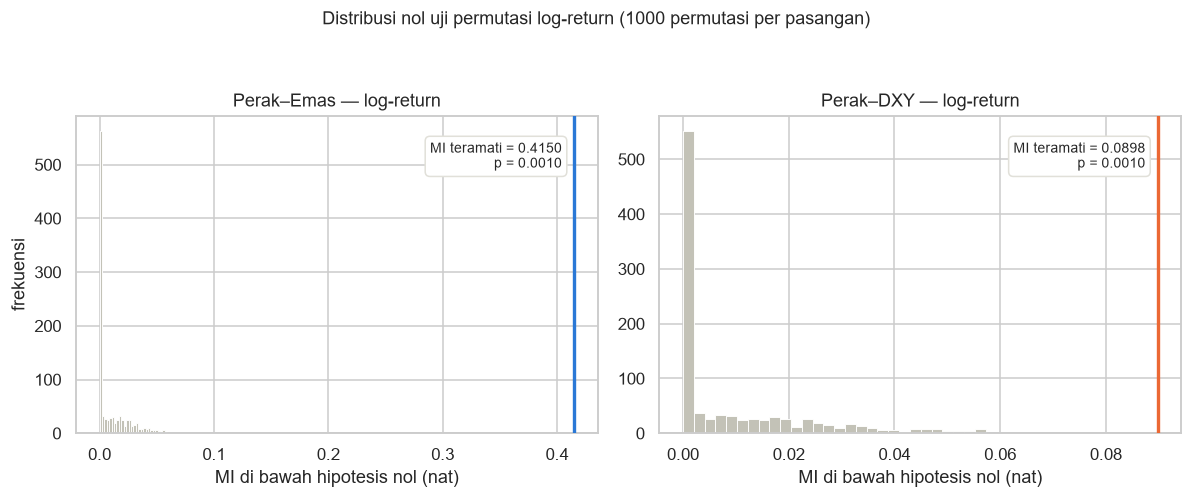

Tersimpan: D:\project-skripsi\results\figures\mutual_information\mi_permutation_null.png


,MI teramati,null mean,null q95,p-value
Pasangan,,,,
Perak–Emas,0.4150,0.0097,0.0423,0.0010
Perak–DXY,0.0898,0.0095,0.0430,0.0010


In [19]:
# Item 22: histogram distribusi null uji permutasi (varian log-return -- varian yang asumsinya sah)
fig, axes = plt.subplots(1, len(COVARIATE_COLS), figsize=(11, 4.6))
axes = np.atleast_1d(axes)

permutation_rows = []
transformed_logret = transform_frame(train, MODE_LOG_RETURN, ALL_COLUMNS).dropna()

for ax, covariate in zip(axes, COVARIATE_COLS):
    mi_observed, null_values = permutation_null_distribution(
        transformed_logret[covariate].to_numpy(),
        transformed_logret[TARGET_COL].to_numpy(),
        n_permutations=MI_SETTINGS["n_permutations"],
        random_state=MI_SETTINGS["random_state"],
        n_neighbors=MI_SETTINGS["n_neighbors"],
    )
    n_ge = int(np.count_nonzero(null_values >= mi_observed))
    p_value = (1 + n_ge) / (1 + len(null_values))
    permutation_rows.append({
        "Pasangan": PAIR_LABELS[covariate], "MI teramati": mi_observed,
        "null mean": null_values.mean(), "null q95": np.quantile(null_values, 0.95),
        "p-value": p_value,
    })

    color = COVARIATE_COLORS[covariate]
    ax.hist(null_values, bins=40, color="#c3c2b7", edgecolor="white", linewidth=0.6)
    ax.axvline(mi_observed, color=color, linewidth=2.2, zorder=3)
    ax.annotate(
        f"MI teramati = {mi_observed:.4f}\np = {p_value:.4f}",
        xy=(mi_observed, ax.get_ylim()[1] * 0.92), xytext=(-8, 0), textcoords="offset points",
        ha="right", va="top", fontsize=9,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#e1e0d9"},
    )
    ax.set_title(f"{PAIR_LABELS[covariate]} \u2014 log-return")
    ax.set_xlabel("MI di bawah hipotesis nol (nat)")

axes[0].set_ylabel("frekuensi")
fig.suptitle(
    f"Distribusi nol uji permutasi log-return ({MI_SETTINGS['n_permutations']} permutasi per pasangan)",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))

mi_null_fig_path = FIGURES_DIR / "mutual_information" / "mi_permutation_null.png"
fig.savefig(mi_null_fig_path)
plt.show()
print("Tersimpan:", mi_null_fig_path)
pd.DataFrame(permutation_rows).set_index("Pasangan")

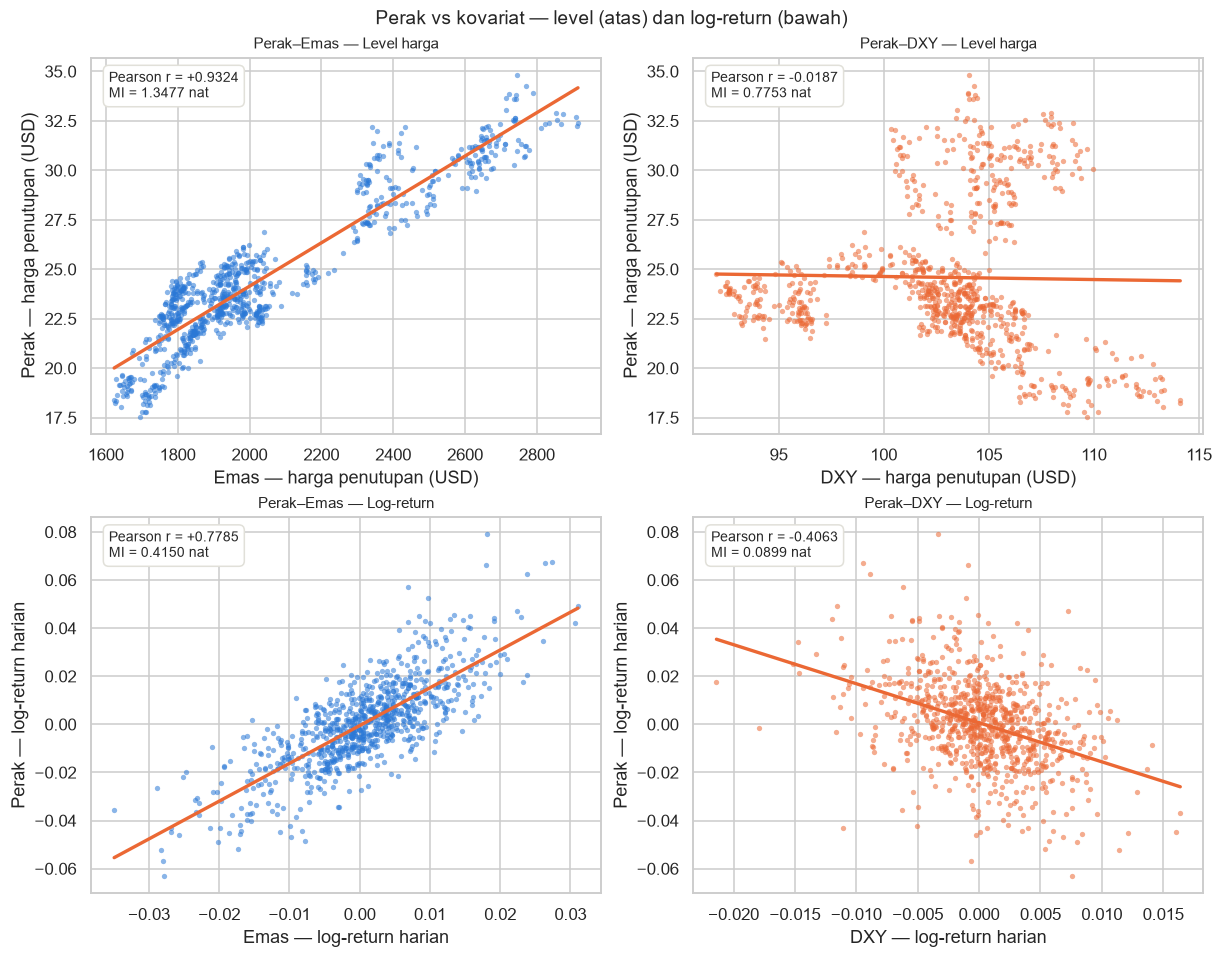

Tersimpan: D:\project-skripsi\results\figures\relationship\scatter_level_vs_return.png


In [20]:
# Item 23: scatter level vs log-return, dengan garis regresi
fig, axes = plt.subplots(2, len(COVARIATE_COLS), figsize=(11, 8.6), layout="constrained")

for row, mode in enumerate(MODES):
    transformed = transform_frame(train, mode, ALL_COLUMNS).dropna()
    unit = "harga penutupan (USD)" if mode == MODE_LEVEL else "log-return harian"

    for col, covariate in enumerate(COVARIATE_COLS):
        ax = axes[row, col]
        x = transformed[covariate].to_numpy()
        y = transformed[TARGET_COL].to_numpy()

        ax.scatter(x, y, s=12, color=COVARIATE_COLORS[covariate], alpha=0.55, linewidths=0, zorder=2)

        slope, intercept = np.polyfit(x, y, 1)
        grid = np.linspace(x.min(), x.max(), 100)
        ax.plot(grid, intercept + slope * grid, color="#eb6834", linewidth=2.2, zorder=3)

        mi_value = mi_results[mode]["pairs"][covariate]["mi_mean"]
        pearson_r = mi_results[mode]["pairs"][covariate]["pearson"]["coefficient"]
        ax.annotate(
            f"Pearson r = {pearson_r:+.4f}\nMI = {mi_value:.4f} nat",
            xy=(0.035, 0.965), xycoords="axes fraction", va="top", fontsize=9,
            bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "#e1e0d9"},
        )
        ax.set_xlabel(f"{NAMES[covariate]} \u2014 {unit}")
        ax.set_ylabel(f"{NAMES[TARGET_COL]} \u2014 {unit}")
        ax.set_title(f"{PAIR_LABELS[covariate]} \u2014 {MODE_LABELS[mode]}", fontsize=10)

fig.suptitle("Perak vs kovariat \u2014 level (atas) dan log-return (bawah)", fontsize=12.5)

scatter_fig_path = FIGURES_DIR / "relationship" / "scatter_level_vs_return.png"
fig.savefig(scatter_fig_path)
plt.show()
print("Tersimpan:", scatter_fig_path)

Pada level harga, titik-titiknya membentuk lintasan rapi yang naik searah — MI yang besar di sana sebagian besar adalah cerminan **tren bersama** (ketiga aset sama-sama bergerak sepanjang periode latih), bukan keterkaitan pergerakan harian. Setelah ditransformasi menjadi log-return, tren itu hilang dan yang tersisa adalah awan titik yang jauh lebih tersebar — MI yang terukur di sana adalah keterkaitan hari-ke-hari yang sesungguhnya, jauh lebih kecil, tetapi inilah yang secara statistik sah untuk disimpulkan. Ini konsisten dengan Bagian 1: ketiga seri non-stasioner pada level dan stasioner pada log-return, sehingga estimator MI pada level pada dasarnya mengukur kesamaan lintasan tren, bukan ketergantungan lokal.

## Bagian 9 — Sintesis

In [21]:
synthesis_rows = []
for covariate in COVARIATE_COLS:
    pearson_r = mi_results[MODE_LOG_RETURN]["pairs"][covariate]["pearson"]["coefficient"]
    mi_logret = mi_results[MODE_LOG_RETURN]["pairs"][covariate]["mi_mean"]
    peak = ccf_results[covariate].loc[ccf_results[covariate]["ccf"].abs().idxmax()]

    forward = granger_validated["pairs"][f"{covariate}->{TARGET_COL}"]
    backward = granger_validated["pairs"][f"{TARGET_COL}->{covariate}"]
    granger_summary = (
        f"{NAMES[covariate]}\u2192{NAMES[TARGET_COL]}: "
        f"{'signifikan' if forward['significant'] else 'tidak signifikan'} (p={forward['p_value']:.3f}); "
        f"{NAMES[TARGET_COL]}\u2192{NAMES[covariate]}: "
        f"{'signifikan' if backward['significant'] else 'tidak signifikan'} (p={backward['p_value']:.3f})"
    )

    if not forward["significant"] and not backward["significant"] and abs(mi_logret) > 0:
        kesimpulan = (
            "keterkaitan bersifat sezaman (lag CCF puncak = 0, MI signifikan pada lag 0), "
            "tanpa presedensi prediktif berlag pada arah manapun"
        )
    else:
        kesimpulan = "lihat catatan pada markdown penutup"

    synthesis_rows.append({
        "Pasangan": PAIR_LABELS[covariate],
        "Pearson r (log-return)": pearson_r,
        "Lag CCF puncak": int(peak["lag"]),
        "Hasil Granger (Toda-Yamamoto, dua arah)": granger_summary,
        "MI log-return (nat)": mi_logret,
        "Kesimpulan gabungan": kesimpulan,
    })

synthesis_table = pd.DataFrame(synthesis_rows).set_index("Pasangan")
synthesis_table

,Pearson r (log-return),Lag CCF puncak,"Hasil Granger (Toda-Yamamoto, dua arah)",MI log-return (nat),Kesimpulan gabungan
Pasangan,,,,,
Perak–Emas,0.7785,0,Emas→Perak: tidak signifikan (p=0.270); Perak→...,0.4150,keterkaitan bersifat sezaman (lag CCF puncak =...
Perak–DXY,-0.4063,0,DXY→Perak: tidak signifikan (p=0.580); Perak→D...,0.0899,keterkaitan bersifat sezaman (lag CCF puncak =...


Granger dan MI **sejalan** pada penelitian ini: begitu diuji pada bentuk berlag (lag ≥ 1), keduanya sepakat tidak menemukan keterkaitan. MI log-return runtuh dari nilai signifikan di lag 0 menjadi mendekati nol begitu lag digeser ke ≥ 1, dan Toda-Yamamoto — yang secara konstruksi hanya menguji lag ≥ 1 — juga tidak menemukan presedensi prediktif signifikan pada keempat arah pengujian, konsisten baik pada lag mentah maupun lag yang sudah divalidasi diagnostik residualnya (Bagian 6–7). Yang justru signifikan dan besar adalah keterkaitan **sezaman**: MI level maupun log-return pada lag 0 signifikan secara statistik untuk kedua pasangan (uji permutasi menolak hipotesis kemandirian, p ≈ 0,001), dan CCF mencapai puncak absolutnya tepat di lag 0 untuk Emas maupun Dollar Index. Pola ini — MI/korelasi tinggi pada lag 0 tetapi tidak ada presedensi prediktif pada lag ≥ 1 — adalah temuan yang konsisten, bukan kegagalan salah satu metode: ia menunjukkan bahwa Perak, Emas, dan Dollar Index bergerak **bersama pada hari yang sama**, bukan bahwa pergerakan salah satunya mendahului dan bisa dipakai menebak pergerakan yang lain di hari berikutnya. Pola sebaliknya (Granger signifikan namun MI rendah, yang akan menandakan keterkaitan linear lemah tetapi konsisten secara temporal) tidak teramati pada data ini untuk pasangan manapun. Sebagai pengetahuan tambahan tentang pola keterkaitan (bukan klaim sebab-akibat), temuan ini menegaskan bahwa manfaat Emas dan Dollar Index sebagai kovariat *past-only* pada Tujuan 2 terletak pada pengayaan konteks pasar yang dibaca model pada setiap titik waktu, bukan pada kemampuan meramalkan pergerakan Perak beberapa hari ke depan semata dari pergerakan kovariat itu sendiri.